# Analytical Robustness of cfDNA Fragmentomic Features

**Nelly Abualkheir**  
Brandeis University  
Week 8 Final Project  
July 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1EAkJHjX7XLJsOOb1J0uHuSiwrgIWxqCU?usp=sharing)

## Week 8 Final Project

### Research Question

How does simulated reduction in sequencing depth affect the stability of global and genome-wide regional cfDNA fragmentomic features, and which features retain sufficient diagnostic performance for cancer-versus-healthy classification at low fragment counts?

### Working Hypothesis

Genome-wide regional fragmentation profiles will provide stronger cancer-versus-healthy discrimination than global fragment-size features because they preserve genomic context. However, regional profiles are expected to become progressively less stable as sequencing depth decreases, leading to reduced classification performance at low fragment counts.

### Analysis Overview

This analysis uses a balanced cohort of 92 plasma cfDNA samples, including 46 breast cancer and 46 healthy controls. Global fragment-size features and genome-wide regional fragmentation profiles are compared at full sequencing depth. Sequencing depth is then computationally reduced to 20M, 10M, 5M, 2M, and 1M fragments per sample to evaluate both regional profile stability and cancer classification performance.

## 1. Setup and Project Configuration

This section mounts Google Drive, defines the project directory structure, and prepares the paths used throughout the analysis. Keeping project paths centralized makes the workflow easier to reproduce and reduces the risk of saving outputs to inconsistent locations.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project"
)

DATA_RAW_DIR = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
METADATA_DIR = PROJECT_DIR / "data" / "metadata"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
SCRIPT_DIR = PROJECT_DIR / "src"
FIGURE_DIR = PROJECT_DIR / "results" / "figures"
TABLE_DIR = PROJECT_DIR / "results" / "tables"
MODEL_DIR = PROJECT_DIR / "results" / "models"
REPORT_DIR = PROJECT_DIR / "report"

folders = [
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    METADATA_DIR,
    NOTEBOOK_DIR,
    SCRIPT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    MODEL_DIR,
    REPORT_DIR,
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.\n")

for folder in folders:
    print(folder)

Project folders created successfully.

/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project/data/raw
/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project/data/processed
/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project/data/metadata
/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project/notebooks
/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project/src
/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project/results/figures
/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project/results/tables
/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project/results/models
/content/drive/MyDrive/cfDNA_Fragmentomics_Depth_Project/report


In [5]:
!pip -q install pandas numpy scipy scikit-learn openpyxl

In [6]:
import sys
import pandas as pd
import numpy as np
import scipy
import sklearn

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.13
pandas: 2.2.2
numpy: 2.0.2
scipy: 1.16.3
scikit-learn: 1.6.1


## 2. Dataset Selection and Feasibility

The dataset was selected from the Cristiano et al. (2019) cfDNA whole-genome fragmentation study because it provides fragment-level plasma data suitable for evaluating both global and regional fragmentomic features.

The final analysis used a balanced cohort of 92 samples, including 46 breast cancer samples and 46 healthy controls. Fragment-level information was required to simulate lower sequencing depths and evaluate how feature stability changes as fragment counts decrease.

## 3. Raw Fragment File Inspection and Pilot Processing

Before processing the full cohort, two pilot samples were used to verify the fragment-file structure, column organization, compression format, and computational requirements.

This pilot step confirmed that fragment coordinates, mapping quality, and strand information could be read correctly and that the full cohort could be processed efficiently in chunks without loading entire files into memory.

In [7]:
from google.colab import drive
from pathlib import Path

# Remount Drive and choose the same Google account
# where the BGZ files are stored.
drive.mount("/content/drive", force_remount=True)

MY_DRIVE = Path("/content/drive/MyDrive")

# Search everywhere in My Drive for the fragment files
raw_files = sorted(MY_DRIVE.rglob("*.frag.tsv.bgz"))

print(f"Number of fragment files found: {len(raw_files)}\n")

for file_path in raw_files:
    size_mb = file_path.stat().st_size / (1024**2)

    print("File:", file_path.name)
    print("Full location:", file_path)
    print(f"Size: {size_mb:,.2f} MB")
    print("-" * 70)

Mounted at /content/drive
Number of fragment files found: 2

File: EE87786.hg38.frag.tsv.bgz
Full location: /content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/raw/EE87786.hg38.frag.tsv.bgz
Size: 259.73 MB
----------------------------------------------------------------------
File: EE87935.hg38.frag.tsv.bgz
Full location: /content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/raw/EE87935.hg38.frag.tsv.bgz
Size: 288.28 MB
----------------------------------------------------------------------


In [8]:
import gzip

for file_path in raw_files:
    print("\n" + "=" * 80)
    print("FILE:", file_path.name)
    print("=" * 80)

    with gzip.open(file_path, mode="rt") as handle:
        for _ in range(5):
            line = handle.readline()

            if not line:
                break

            print(line.rstrip())


FILE: EE87786.hg38.frag.tsv.bgz
chr1	10002	10139	0	+
chr1	10003	10137	4	-
chr1	10003	10143	0	+
chr1	10003	10220	1	+
chr1	10007	10139	6	-

FILE: EE87935.hg38.frag.tsv.bgz
chr1	10000	10149	0	-
chr1	10002	10110	0	-
chr1	10002	10122	1	-
chr1	10002	10136	0	+
chr1	10002	10150	0	+


### 3.1 Pilot Inspection of a Fragment File

Each row represents one mapped cfDNA fragment, with genomic chromosome, start and end coordinates, mapping quality, and strand information. Fragment length was calculated as:

**Fragment length = end coordinate − start coordinate**

A breast cancer pilot sample was first inspected using a limited number of records to verify the file structure and confirm that the required fields could be parsed correctly before full-sample processing.

In [9]:
import shutil
from pathlib import Path

# Select the cancer pilot sample
cancer_drive_file = next(
    file_path
    for file_path in raw_files
    if "EE87786" in file_path.name
)

# Copy it from Google Drive to Colab's faster temporary storage
LOCAL_FILE = Path("/content/EE87786.hg38.frag.tsv.bgz")

if not LOCAL_FILE.exists():
    print("Copying file to Colab temporary storage...")
    shutil.copy2(cancer_drive_file, LOCAL_FILE)
    print("Copy completed.")
else:
    print("Local copy already exists.")

print("Local file:", LOCAL_FILE)
print(f"Local size: {LOCAL_FILE.stat().st_size / (1024**2):,.2f} MB")

Copying file to Colab temporary storage...
Copy completed.
Local file: /content/EE87786.hg38.frag.tsv.bgz
Local size: 259.73 MB


In [10]:
import pandas as pd

column_names = [
    "chrom",
    "start",
    "stop",
    "mapq",
    "strand",
]

pilot_df = pd.read_csv(
    LOCAL_FILE,
    sep="\t",
    header=None,
    names=column_names,
    compression="gzip",
    nrows=200_000,
    dtype={
        "chrom": "category",
        "start": "int32",
        "stop": "int32",
        "mapq": "int16",
        "strand": "category",
    },
)

pilot_df["fragment_length"] = (
    pilot_df["stop"] - pilot_df["start"]
)

print("Rows loaded:", len(pilot_df))
display(pilot_df.head())

Rows loaded: 200000


,chrom,start,stop,mapq,strand,fragment_length
0,chr1,10002,10139,0,+,137
1,chr1,10003,10137,4,-,134
2,chr1,10003,10143,0,+,140
3,chr1,10003,10220,1,+,217
4,chr1,10007,10139,6,-,132


### 3.2 Pilot Fragment Characteristics

The pilot sample was examined to characterize fragment lengths and mapping quality before defining the processing workflow. Fragment-length distributions were summarized to confirm the expected cfDNA size range, while mapping-quality values were evaluated to establish filtering criteria for downstream analysis.

In [11]:
print("Column data types:")
print(pilot_df.dtypes)

print("\nMissing values:")
print(pilot_df.isna().sum())

print("\nMAPQ summary:")
print(pilot_df["mapq"].describe())

print("\nStrand counts:")
print(pilot_df["strand"].value_counts())

print("\nFragment-length summary:")
print(pilot_df["fragment_length"].describe())

print("\nTen most common MAPQ values:")
print(pilot_df["mapq"].value_counts().head(10))

Column data types:
chrom              category
start                 int32
stop                  int32
mapq                  int16
strand             category
fragment_length       int32
dtype: object

Missing values:
chrom              0
start              0
stop               0
mapq               0
strand             0
fragment_length    0
dtype: int64

MAPQ summary:
count    200000.000000
mean         54.165765
std          16.402349
min           0.000000
25%          60.000000
50%          60.000000
75%          60.000000
max          60.000000
Name: mapq, dtype: float64

Strand counts:
strand
-    100152
+     99848
Name: count, dtype: int64

Fragment-length summary:
count    200000.000000
mean        165.951280
std          16.666931
min          99.000000
25%         157.000000
50%         166.000000
75%         175.000000
max         233.000000
Name: fragment_length, dtype: float64

Ten most common MAPQ values:
mapq
60    172485
0      14035
40      3600
27      1254
50      1

In [12]:
invalid_lengths = (
    (pilot_df["fragment_length"] <= 0) |
    (pilot_df["fragment_length"] > 1000)
)

print("Invalid or unusually long fragments:",
      invalid_lengths.sum())

print("\nFragment-length percentiles:")
print(
    pilot_df["fragment_length"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

Invalid or unusually long fragments: 0

Fragment-length percentiles:
0.01    122.0
0.05    138.0
0.25    157.0
0.50    166.0
0.75    175.0
0.95    193.0
0.99    211.0
Name: fragment_length, dtype: float64


In [13]:
high_quality_count = (pilot_df["mapq"] >= 30).sum()
high_quality_percent = (
    high_quality_count / len(pilot_df) * 100
)

print(f"Fragments with MAPQ ≥ 30: {high_quality_count:,}")
print(f"Percentage with MAPQ ≥ 30: {high_quality_percent:.2f}%")

Fragments with MAPQ ≥ 30: 181,294
Percentage with MAPQ ≥ 30: 90.65%


### 3.3 Chunked Fragment Processing

Because the fragment-level files contain millions of records, full samples were processed in chunks rather than loaded entirely into memory. During processing, fragments were filtered using mapping quality and fragment-length criteria, and fragment-length counts were accumulated across chunks.

This approach reduced memory requirements while preserving the information needed for downstream fragmentomic feature generation.

In [14]:
import time
import numpy as np
import pandas as pd

COLUMN_NAMES = ["chrom", "start", "stop", "mapq", "strand"]
CHUNK_SIZE = 1_000_000
MAX_FRAGMENT_LENGTH = 1000

def summarize_fragment_lengths(
    file_path,
    mapq_min=30,
    chunk_size=CHUNK_SIZE,
):
    """
    Stream through one fragment file and generate fragment-length counts.
    The complete file is never loaded into memory.
    """
    length_counts = np.zeros(
        MAX_FRAGMENT_LENGTH + 1,
        dtype=np.int64,
    )

    total_fragments = 0
    high_quality_fragments = 0
    invalid_fragments = 0
    chunk_number = 0

    start_time = time.time()

    reader = pd.read_csv(
        file_path,
        sep="\t",
        header=None,
        names=COLUMN_NAMES,
        compression="gzip",
        chunksize=chunk_size,
        dtype={
            "chrom": "category",
            "start": "int32",
            "stop": "int32",
            "mapq": "int16",
            "strand": "category",
        },
    )

    for chunk in reader:
        chunk_number += 1
        total_fragments += len(chunk)

        # Retain reliably mapped fragments.
        chunk = chunk.loc[chunk["mapq"] >= mapq_min]

        lengths = (
            chunk["stop"].to_numpy()
            - chunk["start"].to_numpy()
        )

        valid = (
            (lengths > 0)
            & (lengths <= MAX_FRAGMENT_LENGTH)
        )

        high_quality_fragments += valid.sum()
        invalid_fragments += (~valid).sum()

        length_counts += np.bincount(
            lengths[valid],
            minlength=MAX_FRAGMENT_LENGTH + 1,
        )

        if chunk_number % 10 == 0:
            elapsed_minutes = (time.time() - start_time) / 60
            print(
                f"Chunks processed: {chunk_number} | "
                f"Rows scanned: {total_fragments:,} | "
                f"Elapsed: {elapsed_minutes:.1f} min"
            )

    elapsed_seconds = time.time() - start_time

    summary = {
        "file": file_path.name,
        "total_fragments": total_fragments,
        "high_quality_fragments": high_quality_fragments,
        "invalid_fragments": invalid_fragments,
        "mapq_threshold": mapq_min,
        "elapsed_minutes": elapsed_seconds / 60,
    }

    length_table = pd.DataFrame({
        "fragment_length": np.arange(
            MAX_FRAGMENT_LENGTH + 1
        ),
        "count": length_counts,
    })

    length_table = length_table.loc[
        length_table["count"] > 0
    ].reset_index(drop=True)

    return summary, length_table

### Pilot Processing Outcome

The pilot analysis confirmed that the fragment files could be processed efficiently using the chunked workflow. Quality filtering and fragment-length calculation were successfully applied across the complete sample, supporting extension of the same processing strategy to the full study cohort.

In [15]:
cancer_summary, cancer_length_counts = (
    summarize_fragment_lengths(LOCAL_FILE)
)

print("\nProcessing summary:")
for key, value in cancer_summary.items():
    print(f"{key}: {value}")

display(cancer_length_counts.head())
display(cancer_length_counts.tail())

Chunks processed: 10 | Rows scanned: 10,000,000 | Elapsed: 0.3 min
Chunks processed: 20 | Rows scanned: 20,000,000 | Elapsed: 0.5 min
Chunks processed: 30 | Rows scanned: 30,000,000 | Elapsed: 0.6 min
Chunks processed: 40 | Rows scanned: 40,000,000 | Elapsed: 0.8 min

Processing summary:
file: EE87786.hg38.frag.tsv.bgz
total_fragments: 41493238
high_quality_fragments: 38080529
invalid_fragments: 0
mapq_threshold: 30
elapsed_minutes: 0.8074817816416423


,fragment_length,count
0,99,137
1,100,3972
2,101,4513
3,102,6296
4,103,6640


,fragment_length,count
130,229,8060
131,230,7753
132,231,6522
133,232,6030
134,233,5557


In [16]:
PROCESSED_DIR = (
    Path("/content/drive/MyDrive/"
         "cfDNA_Fragmentomics_Final_Project/"
         "data/processed")
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

output_file = (
    PROCESSED_DIR
    / "EE87786_fragment_length_counts.csv"
)

cancer_length_counts.to_csv(
    output_file,
    index=False,
)

print("Saved:", output_file)

Saved: /content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/EE87786_fragment_length_counts.csv


In [17]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project"
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

cancer_output = (
    PROCESSED_DIR /
    "EE87786_fragment_length_counts.csv"
)

cancer_length_counts.to_csv(
    cancer_output,
    index=False
)

print("Saved:", cancer_output)
print("Rows saved:", len(cancer_length_counts))

Saved: /content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/EE87786_fragment_length_counts.csv
Rows saved: 135


In [18]:
import shutil
from pathlib import Path

# Find the healthy sample in Google Drive
healthy_drive_file = next(
    file_path
    for file_path in raw_files
    if "EE87935" in file_path.name
)

# Copy it to Colab temporary storage
HEALTHY_LOCAL_FILE = Path(
    "/content/EE87935.hg38.frag.tsv.bgz"
)

if not HEALTHY_LOCAL_FILE.exists():
    print("Copying healthy sample to Colab...")
    shutil.copy2(
        healthy_drive_file,
        HEALTHY_LOCAL_FILE
    )
    print("Copy completed.")
else:
    print("Healthy sample is already in /content.")

print("Local file:", HEALTHY_LOCAL_FILE)
print(
    "Local size:",
    f"{HEALTHY_LOCAL_FILE.stat().st_size / (1024**2):,.2f} MB"
)

Copying healthy sample to Colab...
Copy completed.
Local file: /content/EE87935.hg38.frag.tsv.bgz
Local size: 288.28 MB


In [19]:
healthy_summary, healthy_length_counts = (
    summarize_fragment_lengths(
        HEALTHY_LOCAL_FILE
    )
)

print("\nHealthy-sample processing summary:")

for key, value in healthy_summary.items():
    print(f"{key}: {value}")

display(healthy_length_counts.head())
display(healthy_length_counts.tail())

Chunks processed: 10 | Rows scanned: 10,000,000 | Elapsed: 0.1 min
Chunks processed: 20 | Rows scanned: 20,000,000 | Elapsed: 0.3 min
Chunks processed: 30 | Rows scanned: 30,000,000 | Elapsed: 0.4 min
Chunks processed: 40 | Rows scanned: 40,000,000 | Elapsed: 0.5 min

Healthy-sample processing summary:
file: EE87935.hg38.frag.tsv.bgz
total_fragments: 46491882
high_quality_fragments: 42773071
invalid_fragments: 0
mapq_threshold: 30
elapsed_minutes: 0.5816294550895691


,fragment_length,count
0,72,1
1,73,2
2,76,5
3,77,4
4,78,273


,fragment_length,count
190,264,885
191,265,826
192,266,120
193,267,150
194,268,111


In [20]:
healthy_output = (
    PROCESSED_DIR /
    "EE87935_fragment_length_counts.csv"
)

healthy_length_counts.to_csv(
    healthy_output,
    index=False
)

print("Saved:", healthy_output)

Saved: /content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/EE87935_fragment_length_counts.csv


In [21]:
from pathlib import Path
from collections import defaultdict
import shutil
import time
import gc

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Project settings
# ------------------------------------------------------------

PROJECT_DIR = Path(
    "/content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project"
)

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COLUMN_NAMES = [
    "chrom",
    "start",
    "stop",
    "mapq",
]

AUTOSOMES = {f"chr{i}" for i in range(1, 23)}

CHUNK_SIZE = 1_000_000
BIN_SIZE = 5_000_000

SHORT_MIN = 100
SHORT_MAX = 150

LONG_MIN = 151
LONG_MAX = 220

MAPQ_MIN = 30
MAX_FRAGMENT_LENGTH = 1000


# ------------------------------------------------------------
# Combined processing function
# ------------------------------------------------------------

def extract_fragmentomic_counts(
    file_path,
    sample_id,
    group,
    output_dir=PROCESSED_DIR,
):
    """
    Extract global fragment-length counts and regional short/long
    fragment counts from one FinaleDB fragment file.

    The file is processed in chunks to avoid loading the complete
    dataset into memory.
    """

    start_time = time.time()

    length_counts = np.zeros(
        MAX_FRAGMENT_LENGTH + 1,
        dtype=np.int64,
    )

    regional_counts = defaultdict(
        lambda: {"short": 0, "long": 0}
    )

    total_fragments = 0
    mapq30_fragments = 0
    usable_autosomal_fragments = 0
    regional_fragments = 0
    chunk_number = 0

    reader = pd.read_csv(
        file_path,
        sep="\t",
        header=None,
        names=COLUMN_NAMES,
        usecols=[0, 1, 2, 3],
        compression="gzip",
        chunksize=CHUNK_SIZE,
        dtype={
            "chrom": "string",
            "start": "int32",
            "stop": "int32",
            "mapq": "int16",
        },
    )

    for chunk in reader:
        chunk_number += 1
        total_fragments += len(chunk)

        chrom = chunk["chrom"]
        start = chunk["start"].to_numpy()
        stop = chunk["stop"].to_numpy()
        mapq = chunk["mapq"].to_numpy()

        lengths = stop - start

        mapq_mask = mapq >= MAPQ_MIN
        autosome_mask = chrom.isin(AUTOSOMES).to_numpy()

        valid_mask = (
            mapq_mask
            & autosome_mask
            & (lengths > 0)
            & (lengths <= MAX_FRAGMENT_LENGTH)
        )

        mapq30_fragments += int(mapq_mask.sum())
        usable_autosomal_fragments += int(valid_mask.sum())

        # Global fragment-length distribution
        length_counts += np.bincount(
            lengths[valid_mask],
            minlength=MAX_FRAGMENT_LENGTH + 1,
        )

        # Regional fragments used for short/long ratios
        regional_mask = (
            valid_mask
            & (lengths >= SHORT_MIN)
            & (lengths <= LONG_MAX)
        )

        regional_fragments += int(regional_mask.sum())

        if regional_mask.any():
            selected_lengths = lengths[regional_mask]

            midpoints = (
                start[regional_mask].astype(np.int64)
                + stop[regional_mask].astype(np.int64)
            ) // 2

            bin_starts = (
                midpoints // BIN_SIZE
            ) * BIN_SIZE

            size_class = np.where(
                selected_lengths <= SHORT_MAX,
                "short",
                "long",
            )

            regional_chunk = pd.DataFrame({
                "chrom": chrom.loc[
                    regional_mask
                ].to_numpy(),
                "bin_start": bin_starts,
                "size_class": size_class,
            })

            grouped = (
                regional_chunk
                .groupby(
                    ["chrom", "bin_start", "size_class"],
                    observed=True,
                )
                .size()
            )

            for (
                chromosome,
                bin_start,
                fragment_class,
            ), count in grouped.items():

                key = (
                    chromosome,
                    int(bin_start),
                )

                regional_counts[key][fragment_class] += int(count)

        if chunk_number % 10 == 0:
            elapsed = (time.time() - start_time) / 60

            print(
                f"{sample_id}: "
                f"{total_fragments:,} rows scanned | "
                f"{elapsed:.1f} min"
            )

        del chunk
        gc.collect()

    # --------------------------------------------------------
    # Global fragment-length table
    # --------------------------------------------------------

    length_table = pd.DataFrame({
        "sample_id": sample_id,
        "group": group,
        "fragment_length": np.arange(
            MAX_FRAGMENT_LENGTH + 1
        ),
        "count": length_counts,
    })

    length_table = length_table.loc[
        length_table["count"] > 0
    ].reset_index(drop=True)

    # --------------------------------------------------------
    # Regional short/long table
    # --------------------------------------------------------

    regional_rows = []

    for (
        chromosome,
        bin_start,
    ), counts in regional_counts.items():

        short_count = counts["short"]
        long_count = counts["long"]

        regional_rows.append({
            "sample_id": sample_id,
            "group": group,
            "chrom": chromosome,
            "bin_start": bin_start,
            "bin_end": bin_start + BIN_SIZE,
            "short_count": short_count,
            "long_count": long_count,
            "total_count": short_count + long_count,
            "short_long_ratio": (
                short_count / long_count
                if long_count > 0
                else np.nan
            ),
        })

    regional_table = pd.DataFrame(regional_rows)

    regional_table["chrom_number"] = (
        regional_table["chrom"]
        .str.replace("chr", "", regex=False)
        .astype(int)
    )

    regional_table = (
        regional_table
        .sort_values(["chrom_number", "bin_start"])
        .drop(columns="chrom_number")
        .reset_index(drop=True)
    )

    elapsed_minutes = (
        time.time() - start_time
    ) / 60

    summary_table = pd.DataFrame([{
        "sample_id": sample_id,
        "group": group,
        "total_fragments": total_fragments,
        "mapq30_fragments": mapq30_fragments,
        "usable_autosomal_fragments":
            usable_autosomal_fragments,
        "regional_fragments_100_220":
            regional_fragments,
        "mapq_threshold": MAPQ_MIN,
        "bin_size_bp": BIN_SIZE,
        "elapsed_minutes": elapsed_minutes,
    }])

    # --------------------------------------------------------
    # Save all outputs
    # --------------------------------------------------------

    length_table.to_csv(
        output_dir /
        f"{sample_id}_global_length_counts.csv",
        index=False,
    )

    regional_table.to_csv(
        output_dir /
        f"{sample_id}_regional_counts.csv",
        index=False,
    )

    summary_table.to_csv(
        output_dir /
        f"{sample_id}_qc_summary.csv",
        index=False,
    )

    return summary_table, length_table, regional_table

In [22]:
pilot_samples = [
    {
        "sample_id": "EE87786",
        "group": "Cancer",
        "filename": "EE87786.hg38.frag.tsv.bgz",
    },
    {
        "sample_id": "EE87935",
        "group": "Healthy",
        "filename": "EE87935.hg38.frag.tsv.bgz",
    },
]

pilot_results = {}

for sample in pilot_samples:

    drive_file = RAW_DIR / sample["filename"]
    local_file = Path("/content") / sample["filename"]

    if not local_file.exists():
        print(f"\nCopying {sample['sample_id']} to /content...")
        shutil.copy2(drive_file, local_file)

    print(f"\nProcessing {sample['sample_id']}...")

    summary, lengths, regions = (
        extract_fragmentomic_counts(
            file_path=local_file,
            sample_id=sample["sample_id"],
            group=sample["group"],
        )
    )

    pilot_results[sample["sample_id"]] = {
        "summary": summary,
        "lengths": lengths,
        "regions": regions,
    }

    display(summary)
    display(regions.head())

    # Remove only the temporary Colab copy.
    # The original remains in Google Drive.
    local_file.unlink(missing_ok=True)

    print(f"Finished {sample['sample_id']}.")


Processing EE87786...
EE87786: 10,000,000 rows scanned | 0.2 min
EE87786: 20,000,000 rows scanned | 0.5 min
EE87786: 30,000,000 rows scanned | 0.7 min
EE87786: 40,000,000 rows scanned | 0.9 min


,sample_id,group,total_fragments,mapq30_fragments,usable_autosomal_fragments,regional_fragments_100_220,mapq_threshold,bin_size_bp,elapsed_minutes
0,EE87786,Cancer,41493238,38080529,35870581,35743132,30,5000000,0.944038


,sample_id,group,chrom,bin_start,bin_end,short_count,long_count,total_count,short_long_ratio
0,EE87786,Cancer,chr1,0,5000000,8626,47429,56055,0.181872
1,EE87786,Cancer,chr1,5000000,10000000,11140,58349,69489,0.190920
2,EE87786,Cancer,chr1,10000000,15000000,10454,55427,65881,0.188608
3,EE87786,Cancer,chr1,15000000,20000000,11681,60390,72071,0.193426
4,EE87786,Cancer,chr1,20000000,25000000,11287,57838,69125,0.195149


Finished EE87786.

Processing EE87935...
EE87935: 10,000,000 rows scanned | 0.2 min
EE87935: 20,000,000 rows scanned | 0.4 min
EE87935: 30,000,000 rows scanned | 0.7 min
EE87935: 40,000,000 rows scanned | 1.0 min


,sample_id,group,total_fragments,mapq30_fragments,usable_autosomal_fragments,regional_fragments_100_220,mapq_threshold,bin_size_bp,elapsed_minutes
0,EE87935,Healthy,46491882,42773071,40330080,39696011,30,5000000,1.092864


,sample_id,group,chrom,bin_start,bin_end,short_count,long_count,total_count,short_long_ratio
0,EE87935,Healthy,chr1,0,5000000,12919,49899,62818,0.258903
1,EE87935,Healthy,chr1,5000000,10000000,16005,63739,79744,0.251102
2,EE87935,Healthy,chr1,10000000,15000000,15012,61491,76503,0.244133
3,EE87935,Healthy,chr1,15000000,20000000,17126,66570,83696,0.257263
4,EE87935,Healthy,chr1,20000000,25000000,16489,63567,80056,0.259396


Finished EE87935.


In [23]:
from pathlib import Path
from datetime import datetime, timezone
import importlib.metadata
import json
import pandas as pd

# ------------------------------------------------------------
# Project locations
# ------------------------------------------------------------

PROJECT_DIR = Path(
    "/content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project"
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
METADATA_DIR = PROJECT_DIR / "data" / "metadata"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Confirm the six essential pilot outputs
# ------------------------------------------------------------

expected_files = [
    PROCESSED_DIR / "EE87786_global_length_counts.csv",
    PROCESSED_DIR / "EE87786_regional_counts.csv",
    PROCESSED_DIR / "EE87786_qc_summary.csv",
    PROCESSED_DIR / "EE87935_global_length_counts.csv",
    PROCESSED_DIR / "EE87935_regional_counts.csv",
    PROCESSED_DIR / "EE87935_qc_summary.csv",
]

print("PILOT OUTPUT CHECK\n")

all_saved = True

for file_path in expected_files:
    exists = file_path.exists()
    all_saved = all_saved and exists

    status = "SAVED" if exists else "MISSING"
    size_kb = file_path.stat().st_size / 1024 if exists else 0

    print(f"{status:7} | {size_kb:8.2f} KB | {file_path.name}")

# ------------------------------------------------------------
# Save pilot sample manifest
# ------------------------------------------------------------

pilot_manifest = pd.DataFrame([
    {
        "sample_id": "EE87786",
        "sample_name": "CGPLPA114",
        "group": "Cancer",
        "disease_status": "Bile duct cancer",
        "genome_build": "hg38",
        "platform": "HiSeq 2000",
        "assay": "WGS",
        "study": "Cristiano et al., 2019",
    },
    {
        "sample_id": "EE87935",
        "sample_name": "CGPLH205",
        "group": "Healthy",
        "disease_status": "Healthy",
        "genome_build": "hg38",
        "platform": "HiSeq 2000",
        "assay": "WGS",
        "study": "Cristiano et al., 2019",
    },
])

pilot_manifest.to_csv(
    METADATA_DIR / "pilot_sample_manifest.csv",
    index=False,
)

# ------------------------------------------------------------
# Combine pilot QC summaries
# ------------------------------------------------------------

qc_tables = [
    pd.read_csv(PROCESSED_DIR / "EE87786_qc_summary.csv"),
    pd.read_csv(PROCESSED_DIR / "EE87935_qc_summary.csv"),
]

pilot_qc = pd.concat(qc_tables, ignore_index=True)

pilot_qc.to_csv(
    PROCESSED_DIR / "pilot_qc_combined.csv",
    index=False,
)

# ------------------------------------------------------------
# Save analysis settings
# ------------------------------------------------------------

checkpoint = {
    "checkpoint_time_utc": datetime.now(timezone.utc).isoformat(),
    "genome_build": "hg38",
    "mapq_threshold": 30,
    "autosomes": "chr1-chr22",
    "bin_size_bp": 5_000_000,
    "short_fragment_definition_bp": "100-150",
    "long_fragment_definition_bp": "151-220",
    "maximum_fragment_length_bp": 1000,
    "chunk_size_rows": 1_000_000,
    "pilot_samples_completed": 2,
    "planned_downsampling_fractions": [1.0, 0.75, 0.50, 0.25, 0.10, 0.05],
    "planned_random_seed": 42,
}

with open(
    METADATA_DIR / "pilot_checkpoint.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(checkpoint, handle, indent=2)

# ------------------------------------------------------------
# Save package versions for reproducibility
# ------------------------------------------------------------

packages = [
    "pandas",
    "numpy",
    "scipy",
    "scikit-learn",
    "matplotlib",
]

with open(
    METADATA_DIR / "environment_versions.txt",
    "w",
    encoding="utf-8",
) as handle:
    for package in packages:
        try:
            version = importlib.metadata.version(package)
            handle.write(f"{package}=={version}\n")
        except importlib.metadata.PackageNotFoundError:
            handle.write(f"{package}=not-installed\n")

print("\nCombined pilot QC:")
display(pilot_qc)

if all_saved:
    print("\nCHECKPOINT COMPLETE — all essential pilot files are saved.")
else:
    print("\nWARNING — at least one essential output is missing.")

PILOT OUTPUT CHECK

SAVED   |     3.39 KB | EE87786_global_length_counts.csv
SAVED   |    42.47 KB | EE87786_regional_counts.csv
SAVED   |     0.22 KB | EE87786_qc_summary.csv
SAVED   |     4.96 KB | EE87935_global_length_counts.csv
SAVED   |    43.15 KB | EE87935_regional_counts.csv
SAVED   |     0.22 KB | EE87935_qc_summary.csv

Combined pilot QC:


,sample_id,group,total_fragments,mapq30_fragments,usable_autosomal_fragments,regional_fragments_100_220,mapq_threshold,bin_size_bp,elapsed_minutes
0,EE87786,Cancer,41493238,38080529,35870581,35743132,30,5000000,0.944038
1,EE87935,Healthy,46491882,42773071,40330080,39696011,30,5000000,1.092864



CHECKPOINT COMPLETE — all essential pilot files are saved.


## 4. Full Cohort Processing and Quality Control

After confirming the workflow using one breast cancer and one healthy control pilot sample, the same processing strategy was extended to the full study cohort.

Fragment files were organized by study group and processed using consistent filtering and feature-generation criteria. Cohort-level quality control was then performed to evaluate sample completeness, sequencing depth, usable fragment counts, and group balance before downstream statistical analysis and classification.

### 4.1 Cohort Assembly

Processed QC summaries, global fragment-length counts, and regional fragmentation counts were assembled at the cohort level. Sample identifiers were checked across datasets to confirm consistent representation before downstream analysis.

The final cohort contained 92 samples, with 46 breast cancer samples and 46 healthy controls.

In [24]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path(
    "/content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project"
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

qc_file = PROCESSED_DIR / "cohort_qc_summary.csv"
global_file = PROCESSED_DIR / "cohort_global_length_counts.csv"
regional_file = PROCESSED_DIR / "cohort_regional_counts.csv"

qc = pd.read_csv(qc_file)
global_counts = pd.read_csv(global_file)
regional_counts = pd.read_csv(regional_file)

print("QC shape:", qc.shape)
print("Global shape:", global_counts.shape)
print("Regional shape:", regional_counts.shape)

print("\nSamples:")
print("QC:", qc["sample_id"].nunique())
print("Global:", global_counts["sample_id"].nunique())
print("Regional:", regional_counts["sample_id"].nunique())

print("\nGroups:")
print(qc["group"].value_counts())

QC shape: (92, 9)
Global shape: (15591, 4)
Regional shape: (52440, 9)

Samples:
QC: 92
Global: 92
Regional: 92

Groups:
group
Breast cancer    46
Healthy          46
Name: count, dtype: int64


### 4.2 Cohort Quality Control

Cohort-level QC metrics were evaluated before feature construction and classification. These included total fragment count, the fraction of fragments passing the MAPQ ≥30 threshold, the fraction of usable autosomal fragments, and the number of regional fragments within the selected fragment-length range.

Missing values and the distributions of key QC metrics were examined to identify potential data-quality issues or extreme samples that could influence downstream comparisons.

In [25]:
qc["mapq30_fraction"] = (
    qc["mapq30_fragments"] /
    qc["total_fragments"]
)

qc["usable_autosomal_fraction"] = (
    qc["usable_autosomal_fragments"] /
    qc["total_fragments"]
)

print(qc[
    [
        "total_fragments",
        "mapq30_fraction",
        "usable_autosomal_fraction",
        "regional_fragments_100_220"
    ]
].describe())

print("\nMissing values:")
print(qc.isna().sum())

       total_fragments  mapq30_fraction  usable_autosomal_fraction  \
count     9.200000e+01        92.000000                  92.000000   
mean      4.562794e+07         0.917361                   0.871058   
std       1.739393e+07         0.004330                   0.009659   
min       2.285465e+07         0.908056                   0.855236   
25%       3.693203e+07         0.914627                   0.864331   
50%       4.281694e+07         0.917506                   0.867463   
75%       4.821752e+07         0.919897                   0.881375   
max       1.484749e+08         0.936526                   0.902324   

       regional_fragments_100_220  
count                9.200000e+01  
mean                 3.938782e+07  
std                  1.537187e+07  
min                  1.921901e+07  
25%                  3.166718e+07  
50%                  3.680020e+07  
75%                  4.161954e+07  
max                  1.295233e+08  

Missing values:
sample_id                   

In [26]:
print("Smallest total fragment counts:")
display(
    qc[
        ["sample_id", "group", "total_fragments"]
    ]
    .sort_values("total_fragments")
    .head(10)
)

print("\nLargest total fragment counts:")
display(
    qc[
        ["sample_id", "group", "total_fragments"]
    ]
    .sort_values("total_fragments", ascending=False)
    .head(10)
)

Smallest total fragment counts:


,sample_id,group,total_fragments
40,EE87855,Breast cancer,22854647
43,EE87858,Breast cancer,28409978
29,EE87844,Breast cancer,29923134
59,EE87941,Healthy,30898676
72,EE87954,Healthy,30959055
20,EE87835,Breast cancer,30982423
76,EE87958,Healthy,31656947
21,EE87836,Breast cancer,32124839
18,EE87833,Breast cancer,33090401
5,EE87816,Breast cancer,33126434



Largest total fragment counts:


,sample_id,group,total_fragments
46,EE87920,Healthy,148474921
47,EE87921,Healthy,138809706
37,EE87852,Breast cancer,85610827
65,EE87947,Healthy,65183963
53,EE87934,Healthy,61758146
58,EE87939,Healthy,61503016
7,EE87822,Breast cancer,58832599
56,EE87937,Healthy,58069270
55,EE87936,Healthy,57589041
26,EE87841,Breast cancer,57278868


In [27]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

for f in drive_root.rglob("cohort_*.csv"):
    print(f)

/content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/cohort_qc_summary.csv
/content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/cohort_global_length_counts.csv
/content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/cohort_regional_counts.csv
/content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/cohort_global_features.csv
/content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/cohort_centered_regional_features.csv


### 4.3 Sequencing Depth Assessment

Sequencing depth was compared between the breast cancer and healthy groups to determine whether systematic differences in fragment count could act as a potential confounding factor in downstream classification.

Because sequencing-depth distributions included extreme values and were not assumed to be normally distributed, a two-sided Mann–Whitney U test was used to compare total fragment counts between groups.

In [29]:
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# Group-specific fragment counts
cancer_depth = qc.loc[
    qc["group"] == "Breast cancer",
    "total_fragments"
]

healthy_depth = qc.loc[
    qc["group"] == "Healthy",
    "total_fragments"
]

print("Breast cancer depth summary:")
print(cancer_depth.describe())

print("\nHealthy depth summary:")
print(healthy_depth.describe())

# Non-parametric comparison
u_stat, p_value = mannwhitneyu(
    cancer_depth,
    healthy_depth,
    alternative="two-sided"
)

print("\nMann–Whitney U test")
print("U statistic:", u_stat)
print("p-value:", p_value)

Breast cancer depth summary:
count    4.600000e+01
mean     4.314589e+07
std      9.904310e+06
min      2.285465e+07
25%      3.738153e+07
50%      4.281694e+07
75%      4.784308e+07
max      8.561083e+07
Name: total_fragments, dtype: float64

Healthy depth summary:
count    4.600000e+01
mean     4.810999e+07
std      2.238594e+07
min      3.089868e+07
25%      3.685678e+07
50%      4.290797e+07
75%      5.108503e+07
max      1.484749e+08
Name: total_fragments, dtype: float64

Mann–Whitney U test
U statistic: 986.0
p-value: 0.5766134498537991


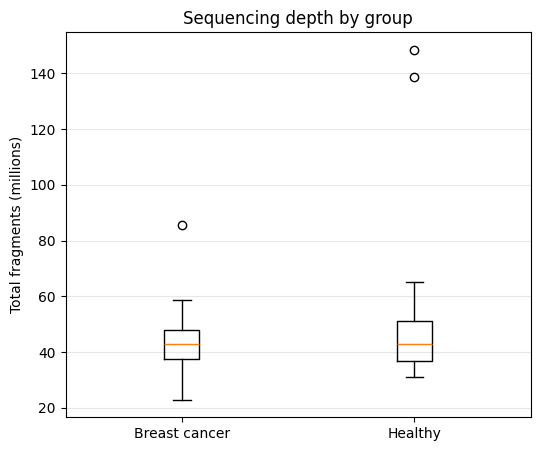

In [30]:
plt.figure(figsize=(6, 5))

data = [
    cancer_depth / 1e6,
    healthy_depth / 1e6
]

plt.boxplot(
    data,
    tick_labels=["Breast cancer", "Healthy"]
)

plt.ylabel("Total fragments (millions)")
plt.title("Sequencing depth by group")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 5. Global Fragmentomic Feature Analysis

Global fragment-size features were derived from the fragment-length distribution of each sample to summarize overall cfDNA fragmentation patterns independent of genomic location.

Features included mean and median fragment length, fragment-length variability, proportions of fragments within selected size ranges, the short-to-long fragment ratio, and fragment-length entropy. These features were calculated consistently across all 92 samples for comparison between breast cancer and healthy controls and for downstream classification.

In [31]:
import numpy as np
import pandas as pd

def weighted_median(values, weights):
    order = np.argsort(values)
    values = np.asarray(values)[order]
    weights = np.asarray(weights)[order]

    cumulative = np.cumsum(weights)
    cutoff = weights.sum() / 2

    return values[np.searchsorted(cumulative, cutoff)]


def calculate_global_features(df):
    rows = []

    for (sample_id, group), sample in df.groupby(
        ["sample_id", "group"]
    ):
        lengths = sample["fragment_length"].to_numpy()
        counts = sample["count"].to_numpy()

        total = counts.sum()

        mean_length = np.average(
            lengths,
            weights=counts
        )

        median_length = weighted_median(
            lengths,
            counts
        )

        variance = np.average(
            (lengths - mean_length) ** 2,
            weights=counts
        )

        std_length = np.sqrt(variance)

        short_100_150 = counts[
            (lengths >= 100) &
            (lengths <= 150)
        ].sum()

        long_151_220 = counts[
            (lengths >= 151) &
            (lengths <= 220)
        ].sum()

        below_150 = counts[
            lengths < 150
        ].sum()

        probabilities = counts / total
        entropy = -np.sum(
            probabilities * np.log2(probabilities)
        )

        rows.append({
            "sample_id": sample_id,
            "group": group,
            "mean_length": mean_length,
            "median_length": median_length,
            "std_length": std_length,
            "pct_below_150": below_150 / total,
            "pct_100_150": short_100_150 / total,
            "pct_151_220": long_151_220 / total,
            "short_long_ratio": (
                short_100_150 / long_151_220
                if long_151_220 > 0
                else np.nan
            ),
            "fragment_entropy": entropy,
        })

    return pd.DataFrame(rows)


global_features = calculate_global_features(global_counts)

print("Shape:", global_features.shape)
print("\nGroups:")
print(global_features["group"].value_counts())

display(global_features.head())

Shape: (92, 10)

Groups:
group
Breast cancer    46
Healthy          46
Name: count, dtype: int64


,sample_id,group,mean_length,median_length,std_length,pct_below_150,pct_100_150,pct_151_220,short_long_ratio,fragment_entropy
0,EE87811,Breast cancer,165.731754,167,19.812582,0.186692,0.198002,0.793384,0.249566,6.306830
1,EE87812,Breast cancer,169.752864,169,18.601605,0.119763,0.129458,0.859237,0.150666,6.206122
2,EE87813,Breast cancer,169.435032,169,19.206598,0.131219,0.141027,0.845895,0.166719,6.251782
3,EE87814,Breast cancer,168.759979,168,18.450540,0.129284,0.139504,0.850647,0.163997,6.191832
4,EE87815,Breast cancer,165.874737,167,19.730148,0.183825,0.194568,0.797120,0.244088,6.293563


In [32]:
global_features.to_csv(
    PROCESSED_DIR / "cohort_global_features.csv",
    index=False
)

print("Saved cohort_global_features.csv")

Saved cohort_global_features.csv


### 5.1 Global Feature Construction

Eight global fragmentomic features were calculated for each of the 92 samples. Sample identifiers and diagnostic groups were retained as metadata for statistical comparison and classification.

In [33]:
import numpy as np
import pandas as pd

def weighted_median(values, weights):
    order = np.argsort(values)
    values = np.asarray(values)[order]
    weights = np.asarray(weights)[order]

    cumulative = np.cumsum(weights)
    cutoff = weights.sum() / 2

    return values[np.searchsorted(cumulative, cutoff)]


def calculate_global_features(df):
    rows = []

    for (sample_id, group), sample in df.groupby(
        ["sample_id", "group"]
    ):
        lengths = sample["fragment_length"].to_numpy()
        counts = sample["count"].to_numpy()

        total = counts.sum()

        mean_length = np.average(
            lengths,
            weights=counts
        )

        median_length = weighted_median(
            lengths,
            counts
        )

        variance = np.average(
            (lengths - mean_length) ** 2,
            weights=counts
        )

        std_length = np.sqrt(variance)

        short_100_150 = counts[
            (lengths >= 100) &
            (lengths <= 150)
        ].sum()

        long_151_220 = counts[
            (lengths >= 151) &
            (lengths <= 220)
        ].sum()

        below_150 = counts[
            lengths < 150
        ].sum()

        probabilities = counts / total
        entropy = -np.sum(
            probabilities * np.log2(probabilities)
        )

        rows.append({
            "sample_id": sample_id,
            "group": group,
            "mean_length": mean_length,
            "median_length": median_length,
            "std_length": std_length,
            "pct_below_150": below_150 / total,
            "pct_100_150": short_100_150 / total,
            "pct_151_220": long_151_220 / total,
            "short_long_ratio": (
                short_100_150 / long_151_220
                if long_151_220 > 0
                else np.nan
            ),
            "fragment_entropy": entropy,
        })

    return pd.DataFrame(rows)


global_features = calculate_global_features(global_counts)

print("Shape:", global_features.shape)
print("\nGroups:")
print(global_features["group"].value_counts())

display(global_features.head())

Shape: (92, 10)

Groups:
group
Breast cancer    46
Healthy          46
Name: count, dtype: int64


,sample_id,group,mean_length,median_length,std_length,pct_below_150,pct_100_150,pct_151_220,short_long_ratio,fragment_entropy
0,EE87811,Breast cancer,165.731754,167,19.812582,0.186692,0.198002,0.793384,0.249566,6.306830
1,EE87812,Breast cancer,169.752864,169,18.601605,0.119763,0.129458,0.859237,0.150666,6.206122
2,EE87813,Breast cancer,169.435032,169,19.206598,0.131219,0.141027,0.845895,0.166719,6.251782
3,EE87814,Breast cancer,168.759979,168,18.450540,0.129284,0.139504,0.850647,0.163997,6.191832
4,EE87815,Breast cancer,165.874737,167,19.730148,0.183825,0.194568,0.797120,0.244088,6.293563


### 5.2 Global Feature Comparison

Global fragmentomic features were compared between breast cancer and healthy samples using two-sided Mann–Whitney U tests. Benjamini–Hochberg correction was applied across the tested features to control the false discovery rate, and rank-biserial correlation was calculated to describe effect size.

In [34]:
from scipy.stats import mannwhitneyu
import pandas as pd

feature_cols = [
    "mean_length",
    "median_length",
    "std_length",
    "pct_below_150",
    "pct_100_150",
    "pct_151_220",
    "short_long_ratio",
    "fragment_entropy"
]

results = []

for feature in feature_cols:

    cancer = global_features.loc[
        global_features["group"] == "Breast cancer",
        feature
    ]

    healthy = global_features.loc[
        global_features["group"] == "Healthy",
        feature
    ]

    u_stat, p_value = mannwhitneyu(
        cancer,
        healthy,
        alternative="two-sided"
    )

    results.append({
        "feature": feature,
        "cancer_median": cancer.median(),
        "healthy_median": healthy.median(),
        "difference": cancer.median() - healthy.median(),
        "p_value": p_value
    })

feature_comparison = pd.DataFrame(results)
feature_comparison = feature_comparison.sort_values("p_value")

display(feature_comparison)

,feature,cancer_median,healthy_median,difference,p_value
7,fragment_entropy,6.254046,6.305067,-0.051021,0.008210
2,std_length,19.200796,19.833642,-0.632846,0.012597
5,pct_151_220,0.815248,0.806688,0.008560,0.388200
1,median_length,167.000000,167.000000,0.000000,0.450042
3,pct_below_150,0.165107,0.171348,-0.006241,0.474908
6,short_long_ratio,0.216283,0.226052,-0.009769,0.479748
4,pct_100_150,0.176324,0.182503,-0.006179,0.504349
0,mean_length,166.335873,167.013554,-0.677682,0.529599


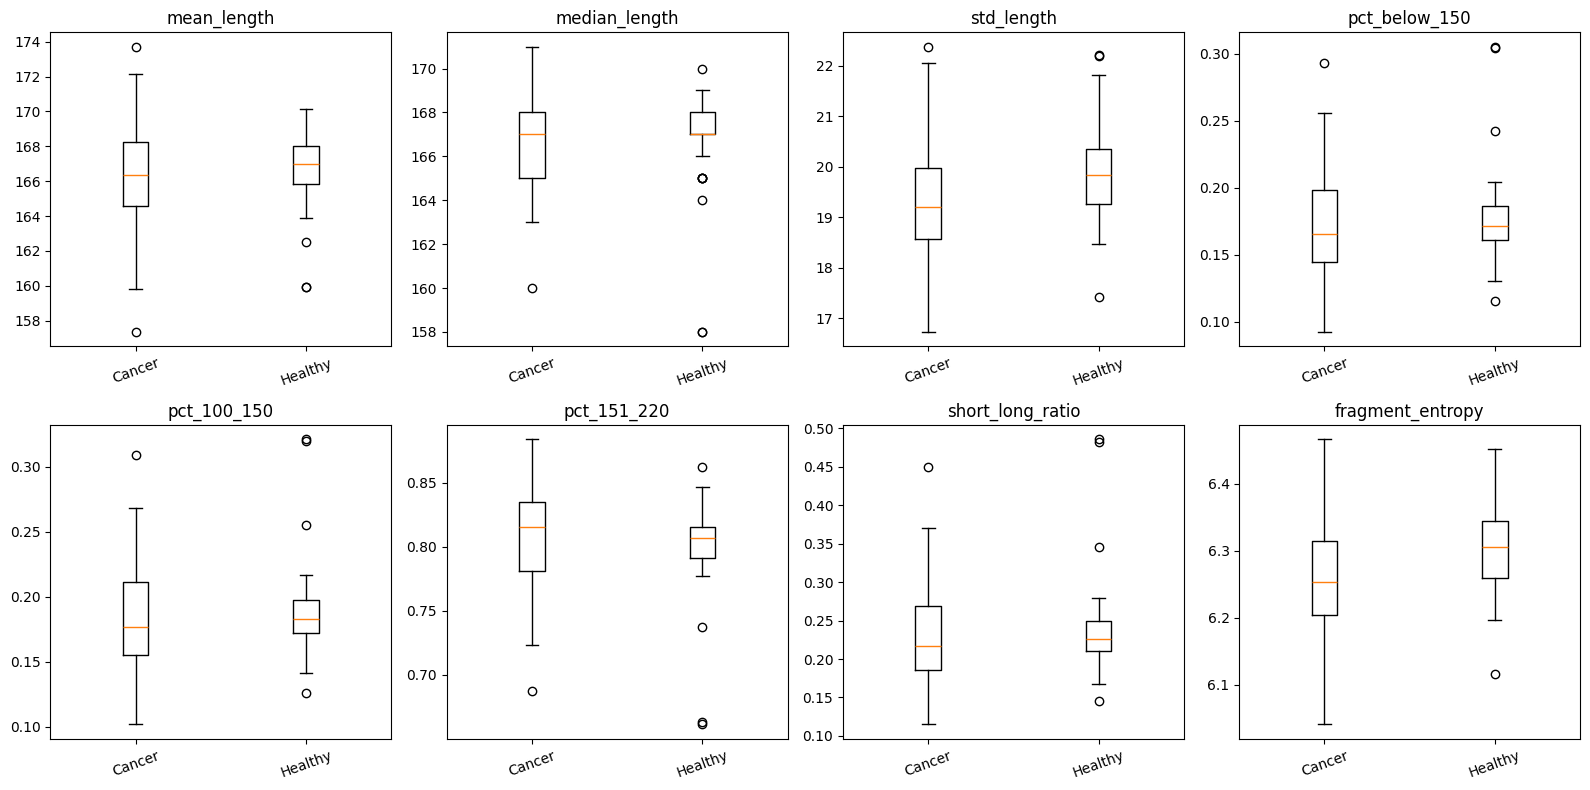

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, feature_cols):

    cancer = global_features.loc[
        global_features["group"] == "Breast cancer",
        feature
    ]

    healthy = global_features.loc[
        global_features["group"] == "Healthy",
        feature
    ]

    ax.boxplot(
        [cancer, healthy],
        tick_labels=["Cancer", "Healthy"]
    )

    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [36]:
from statsmodels.stats.multitest import multipletests

feature_comparison["fdr_p_value"] = multipletests(
    feature_comparison["p_value"],
    method="fdr_bh"
)[1]

feature_comparison["fdr_significant"] = (
    feature_comparison["fdr_p_value"] < 0.05
)

display(
    feature_comparison.sort_values("fdr_p_value")
)

,feature,cancer_median,healthy_median,difference,p_value,fdr_p_value,fdr_significant
7,fragment_entropy,6.254046,6.305067,-0.051021,0.008210,0.050390,False
2,std_length,19.200796,19.833642,-0.632846,0.012597,0.050390,False
5,pct_151_220,0.815248,0.806688,0.008560,0.388200,0.529599,False
1,median_length,167.000000,167.000000,0.000000,0.450042,0.529599,False
3,pct_below_150,0.165107,0.171348,-0.006241,0.474908,0.529599,False
6,short_long_ratio,0.216283,0.226052,-0.009769,0.479748,0.529599,False
4,pct_100_150,0.176324,0.182503,-0.006179,0.504349,0.529599,False
0,mean_length,166.335873,167.013554,-0.677682,0.529599,0.529599,False


In [37]:
import numpy as np
from scipy.stats import mannwhitneyu

effect_results = []

for feature in feature_cols:

    cancer = global_features.loc[
        global_features["group"] == "Breast cancer",
        feature
    ].to_numpy()

    healthy = global_features.loc[
        global_features["group"] == "Healthy",
        feature
    ].to_numpy()

    u_stat, p_value = mannwhitneyu(
        cancer,
        healthy,
        alternative="two-sided"
    )

    n1 = len(cancer)
    n2 = len(healthy)

    rank_biserial = (
        2 * u_stat / (n1 * n2)
    ) - 1

    effect_results.append({
        "feature": feature,
        "rank_biserial": rank_biserial
    })

effect_size_df = pd.DataFrame(effect_results)

feature_comparison = feature_comparison.merge(
    effect_size_df,
    on="feature"
)

display(
    feature_comparison.sort_values(
        "fdr_p_value"
    )
)

,feature,cancer_median,healthy_median,difference,p_value,fdr_p_value,fdr_significant,rank_biserial
0,fragment_entropy,6.254046,6.305067,-0.051021,0.008210,0.050390,False,-0.320416
1,std_length,19.200796,19.833642,-0.632846,0.012597,0.050390,False,-0.302457
2,pct_151_220,0.815248,0.806688,0.008560,0.388200,0.529599,False,0.104915
3,median_length,167.000000,167.000000,0.000000,0.450042,0.529599,False,-0.090265
4,pct_below_150,0.165107,0.171348,-0.006241,0.474908,0.529599,False,-0.086957
5,short_long_ratio,0.216283,0.226052,-0.009769,0.479748,0.529599,False,-0.086011
6,pct_100_150,0.176324,0.182503,-0.006179,0.504349,0.529599,False,-0.081285
7,mean_length,166.335873,167.013554,-0.677682,0.529599,0.529599,False,-0.076560


## 6. Regional Fragmentomic Feature Analysis

Genome-wide regional fragmentation features were constructed to preserve genomic context that is lost in global fragment-size summaries.

For each sample, short-to-long fragment ratios were calculated across 5-Mb genomic bins. These regional values were assembled into a sample-by-region feature matrix for dimensionality reduction, classification, and sequencing-depth robustness analysis.

In [38]:
regional_counts["region"] = (
    regional_counts["chrom"].astype(str)
    + "_"
    + regional_counts["bin_start"].astype(str)
)

regional_matrix = (
    regional_counts
    .pivot(
        index=["sample_id", "group"],
        columns="region",
        values="short_long_ratio"
    )
    .reset_index()
)

print("Regional matrix shape:", regional_matrix.shape)

print("\nGroups:")
print(regional_matrix["group"].value_counts())

print("\nMissing regional values:")
print(
    regional_matrix
    .drop(columns=["sample_id", "group"])
    .isna()
    .sum()
    .sum()
)

display(regional_matrix.iloc[:, :10].head())

Regional matrix shape: (92, 572)

Groups:
group
Breast cancer    46
Healthy          46
Name: count, dtype: int64

Missing regional values:
0


region,sample_id,group,chr10_0,chr10_10000000,chr10_100000000,chr10_105000000,chr10_110000000,chr10_115000000,chr10_120000000,chr10_125000000
0,EE87811,Breast cancer,0.252476,0.256258,0.265513,0.231406,0.251132,0.241525,0.248909,0.241713
1,EE87812,Breast cancer,0.146728,0.154267,0.155688,0.141439,0.152149,0.145771,0.142886,0.141589
2,EE87813,Breast cancer,0.167502,0.170761,0.173390,0.154993,0.168205,0.158442,0.162565,0.155511
3,EE87814,Breast cancer,0.160773,0.165785,0.173075,0.156546,0.161683,0.157616,0.156753,0.156538
4,EE87815,Breast cancer,0.235392,0.245550,0.251061,0.229929,0.247758,0.232993,0.233984,0.232513


### 6.1 Initial PCA of Regional Fragmentation Profiles

Before centering, PCA was applied to the regional fragmentation matrix to evaluate the dominant sources of variation across genome-wide fragmentation profiles. Regional features were standardized before PCA so that genomic regions contributed on a comparable scale.

The relationship between the resulting principal components and sample-level sequencing and QC metrics was also examined to determine whether the dominant variation reflected regional biological structure or broader global and technical effects.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Regional feature columns only
regional_feature_cols = [
    col for col in regional_matrix.columns
    if col not in ["sample_id", "group"]
]

X_regional = regional_matrix[regional_feature_cols]

# Standardize each genomic region
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_regional)

# PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "sample_id": regional_matrix["sample_id"],
    "group": regional_matrix["group"],
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1]
})

print("Variance explained:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(
    "PC1 + PC2:",
    round(pca.explained_variance_ratio_[:2].sum(), 3)
)

display(pca_df.head())

Variance explained:
PC1: 0.989
PC2: 0.006
PC1 + PC2: 0.995


,sample_id,group,PC1,PC2
0,EE87811,Breast cancer,5.233513,-0.818637
1,EE87812,Breast cancer,-30.525013,-0.155726
2,EE87813,Breast cancer,-24.883550,-0.705794
3,EE87814,Breast cancer,-25.772536,-0.386538
4,EE87815,Breast cancer,3.100787,1.719634


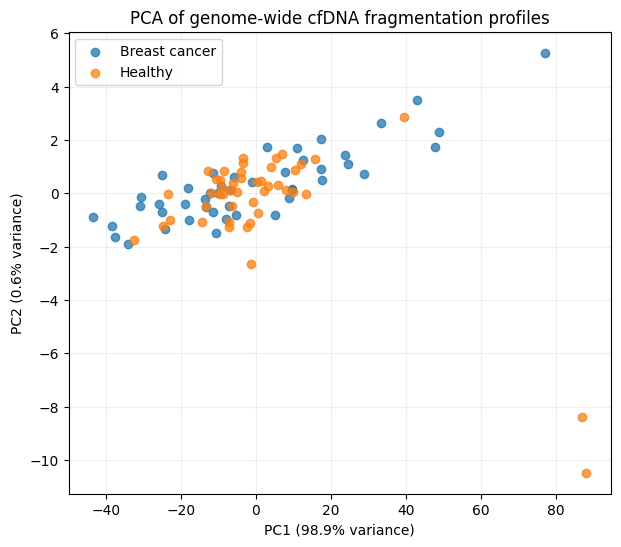

In [40]:
plt.figure(figsize=(7, 6))

for group in ["Breast cancer", "Healthy"]:
    subset = pca_df[pca_df["group"] == group]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=group,
        alpha=0.75
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)
plt.title("PCA of genome-wide cfDNA fragmentation profiles")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [41]:
# Add PC1/PC2 to sample-level data
pca_check = pca_df.merge(
    global_features,
    on=["sample_id", "group"],
    how="left"
).merge(
    qc[
        [
            "sample_id",
            "total_fragments",
            "mapq30_fraction",
            "usable_autosomal_fraction"
        ]
    ],
    on="sample_id",
    how="left"
)

# Correlation of PC1 with global/QC measurements
check_cols = [
    "PC1",
    "mean_length",
    "std_length",
    "pct_below_150",
    "pct_100_150",
    "pct_151_220",
    "short_long_ratio",
    "fragment_entropy",
    "total_fragments",
    "mapq30_fraction",
    "usable_autosomal_fraction"
]

pc1_corr = (
    pca_check[check_cols]
    .corr(method="spearman")["PC1"]
    .drop("PC1")
    .sort_values(key=abs, ascending=False)
)

print("Spearman correlations with PC1:")
display(pc1_corr)

print("\nSamples with lowest PC1:")
display(
    pca_check[
        ["sample_id", "group", "PC1", "PC2",
         "short_long_ratio", "total_fragments"]
    ]
    .sort_values("PC1")
    .head(8)
)

print("\nSamples with highest PC1:")
display(
    pca_check[
        ["sample_id", "group", "PC1", "PC2",
         "short_long_ratio", "total_fragments"]
    ]
    .sort_values("PC1", ascending=False)
    .head(8)
)

Spearman correlations with PC1:


,PC1
short_long_ratio,0.999969
pct_100_150,0.999692
pct_below_150,0.999229
pct_151_220,-0.993712
mean_length,-0.931831
total_fragments,0.162308
mapq30_fraction,0.123515
usable_autosomal_fraction,0.120941
std_length,0.042816
fragment_entropy,0.019759



Samples with lowest PC1:


,sample_id,group,PC1,PC2,short_long_ratio,total_fragments
45,EE87860,Breast cancer,-43.308071,-0.884288,0.114988,38257934
21,EE87836,Breast cancer,-38.246463,-1.235775,0.129421,32124839
40,EE87855,Breast cancer,-37.539462,-1.647747,0.130751,22854647
43,EE87858,Breast cancer,-34.012811,-1.902928,0.140824,28409978
58,EE87939,Healthy,-32.471117,-1.751868,0.145610,61503016
39,EE87854,Breast cancer,-30.716015,-0.462756,0.150187,46958353
1,EE87812,Breast cancer,-30.525013,-0.155726,0.150666,45786511
3,EE87814,Breast cancer,-25.772536,-0.386538,0.163997,45961291



Samples with highest PC1:


,sample_id,group,PC1,PC2,short_long_ratio,total_fragments
46,EE87920,Healthy,88.150756,-10.477078,0.485777,148474921
47,EE87921,Healthy,86.901242,-8.387867,0.481760,138809706
22,EE87837,Breast cancer,77.158969,5.266597,0.449989,52911829
5,EE87816,Breast cancer,48.870973,2.307844,0.370569,33126434
26,EE87841,Breast cancer,47.729812,1.715349,0.368806,57278868
10,EE87825,Breast cancer,43.082408,3.484774,0.355099,51621068
70,EE87952,Healthy,39.634698,2.868820,0.345771,39791918
33,EE87848,Breast cancer,33.459676,2.647898,0.328455,47584361


### 6.2 Regional Feature Centering

The initial PCA indicated that the regional feature matrix was dominated by a strong sample-wide fragmentation signal. To better isolate relative regional variation, regional short-to-long ratios were log-transformed and centered within each sample by subtracting the sample-wide mean.

This transformation reduced the influence of overall fragmentation level while preserving relative differences among genomic regions for downstream analysis.

In [42]:
import numpy as np
import pandas as pd

# Copy the regional matrix
regional_centered = regional_matrix.copy()

regional_feature_cols = [
    c for c in regional_centered.columns
    if c not in ["sample_id", "group"]
]

# Use log ratio to reduce skew
X = np.log2(
    regional_centered[regional_feature_cols] + 1e-6
)

# Remove each sample's genome-wide mean log-ratio
sample_mean = X.mean(axis=1)

X_centered = X.sub(sample_mean, axis=0)

centered_matrix = pd.concat(
    [
        regional_centered[["sample_id", "group"]].reset_index(drop=True),
        X_centered.reset_index(drop=True)
    ],
    axis=1
)

print("Centered matrix shape:", centered_matrix.shape)

print(
    "Average row mean after centering:",
    X_centered.mean(axis=1).abs().mean()
)

display(centered_matrix.iloc[:, :10].head())

Centered matrix shape: (92, 572)
Average row mean after centering: 1.1468578438816663e-15


region,sample_id,group,chr10_0,chr10_10000000,chr10_100000000,chr10_105000000,chr10_110000000,chr10_115000000,chr10_120000000,chr10_125000000
0,EE87811,Breast cancer,0.008905,0.030355,0.081541,-0.116812,0.001204,-0.055065,-0.011621,-0.053941
1,EE87812,Breast cancer,-0.043015,0.029265,0.042492,-0.095984,0.009327,-0.052459,-0.081301,-0.094454
2,EE87813,Breast cancer,0.006038,0.033845,0.055884,-0.105932,0.012080,-0.074183,-0.037122,-0.101123
3,EE87814,Breast cancer,-0.031547,0.012746,0.074823,-0.069986,-0.023400,-0.060154,-0.068080,-0.070055
4,EE87815,Breast cancer,-0.054780,0.006176,0.038198,-0.088654,0.019091,-0.069557,-0.063430,-0.072530


### 6.3 PCA of Centered Regional Profiles

PCA was repeated using the centered regional feature matrix to evaluate genome-wide fragmentation structure after reducing the dominant sample-wide signal. Features were standardized before PCA, allowing the analysis to assess whether additional regional patterns became apparent after centering.

Centered PCA variance explained:
PC1: 0.3682
PC2: 0.0708
PC1 + PC2: 0.439


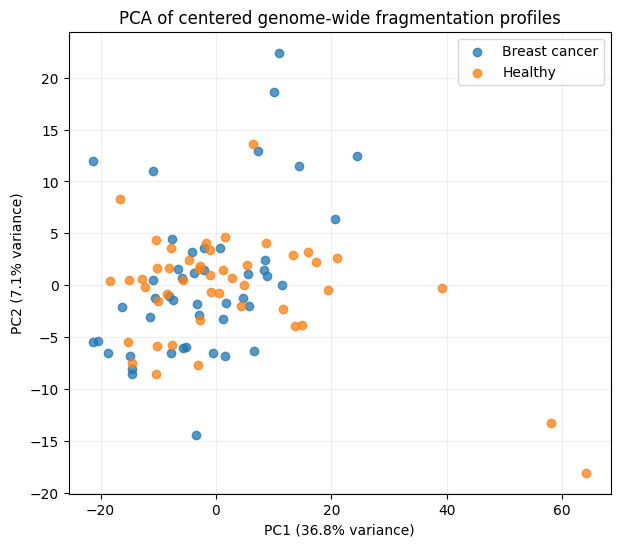

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_centered_values = centered_matrix[regional_feature_cols]

scaler_centered = StandardScaler()
X_centered_scaled = scaler_centered.fit_transform(
    X_centered_values
)

pca_centered = PCA(n_components=10)

centered_pcs = pca_centered.fit_transform(
    X_centered_scaled
)

centered_pca_df = pd.DataFrame({
    "sample_id": centered_matrix["sample_id"],
    "group": centered_matrix["group"],
    "PC1": centered_pcs[:, 0],
    "PC2": centered_pcs[:, 1],
})

print("Centered PCA variance explained:")
print(
    "PC1:",
    round(pca_centered.explained_variance_ratio_[0], 4)
)
print(
    "PC2:",
    round(pca_centered.explained_variance_ratio_[1], 4)
)
print(
    "PC1 + PC2:",
    round(
        pca_centered.explained_variance_ratio_[:2].sum(),
        4
    )
)

plt.figure(figsize=(7, 6))

for group in ["Breast cancer", "Healthy"]:
    subset = centered_pca_df[
        centered_pca_df["group"] == group
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=group,
        alpha=0.75
    )

plt.xlabel(
    f"PC1 ({pca_centered.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca_centered.explained_variance_ratio_[1]*100:.1f}% variance)"
)
plt.title(
    "PCA of centered genome-wide fragmentation profiles"
)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [44]:
centered_matrix.to_csv(
    PROCESSED_DIR / "cohort_centered_regional_features.csv",
    index=False
)

print(
    "Saved:",
    PROCESSED_DIR / "cohort_centered_regional_features.csv"
)

Saved: /content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/cohort_centered_regional_features.csv


## 7. Full-Depth Classification

Supervised classification was used to evaluate how well different fragmentomic feature sets distinguished breast cancer from healthy controls at full sequencing depth.

Logistic regression with L2 regularization was implemented within a standardized preprocessing pipeline. Model performance was evaluated using repeated stratified 5-fold cross-validation with 10 repeats. ROC-AUC was used as the primary performance metric, with accuracy, F1 score, and balanced accuracy reported as supporting measures.

### 7.1 Regional Feature Model

The centered regional fragmentation matrix was used to evaluate whether genome-wide regional patterns provided sufficient discrimination between breast cancer and healthy samples.

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

X = centered_matrix[regional_feature_cols]
y = (centered_matrix["group"] == "Breast cancer").astype(int)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=5000
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy"
}

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    values = cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{values.mean():.3f} ± {values.std():.3f}"
    )

roc_auc: 0.917 ± 0.056
accuracy: 0.850 ± 0.068
f1: 0.844 ± 0.070
balanced_accuracy: 0.850 ± 0.068


### 7.2 Global Feature Model

A second model was trained using only global fragment-size summary features. This provided a direct comparison between overall fragment-size characteristics and genome-wide regional fragmentation patterns.

In [46]:
global_feature_cols = [
    "mean_length",
    "median_length",
    "std_length",
    "pct_below_150",
    "pct_100_150",
    "pct_151_220",
    "short_long_ratio",
    "fragment_entropy"
]

X_global = global_features[global_feature_cols]
y_global = (global_features["group"] == "Breast cancer").astype(int)

global_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=5000
    ))
])

global_cv_results = cross_validate(
    global_model,
    X_global,
    y_global,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    values = global_cv_results[f"test_{metric}"]
    print(
        f"{metric}: "
        f"{values.mean():.3f} ± {values.std():.3f}"
    )

roc_auc: 0.646 ± 0.114
accuracy: 0.577 ± 0.096
f1: 0.569 ± 0.105
balanced_accuracy: 0.578 ± 0.095


### 7.3 Combined Global and Regional Model

Global and centered regional features were combined to test whether global fragment-size information added predictive value beyond the regional fragmentation profile alone.

In [47]:
# Merge global and centered regional features by sample
combined_features = centered_matrix.merge(
    global_features,
    on=["sample_id", "group"],
    how="inner"
)

combined_feature_cols = (
    regional_feature_cols
    + global_feature_cols
)

X_combined = combined_features[combined_feature_cols]
y_combined = (
    combined_features["group"] == "Breast cancer"
).astype(int)

combined_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=5000
    ))
])

combined_cv_results = cross_validate(
    combined_model,
    X_combined,
    y_combined,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    values = combined_cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{values.mean():.3f} ± {values.std():.3f}"
    )

roc_auc: 0.921 ± 0.057
accuracy: 0.858 ± 0.062
f1: 0.854 ± 0.065
balanced_accuracy: 0.858 ± 0.063


## 8. Sequencing-Depth Robustness Analysis

To evaluate the robustness of cfDNA fragmentomic features to reduced sequencing depth, fragment counts were computationally downsampled to progressively lower target depths.

Downsampling was performed using binomial sampling of the observed regional short- and long-fragment counts, with sampling probability determined by the ratio of the target fragment count to the original sample depth. This approach preserves the underlying regional structure while approximating the sampling variability expected as sequencing depth decreases.

Target depths of 20M, 10M, 5M, 2M, and 1M fragments per sample were evaluated and compared with the full-depth data.

In [48]:
import numpy as np
import pandas as pd

def downsample_regional_sample(sample_df, target_fragments, rng):
    """
    Approximate random downsampling by independently thinning
    regional short and long fragment counts.

    target_fragments refers to total raw fragments.
    """

    sample_id = sample_df["sample_id"].iloc[0]

    total_depth = qc.loc[
        qc["sample_id"] == sample_id,
        "total_fragments"
    ].iloc[0]

    if target_fragments > total_depth:
        raise ValueError(
            f"{sample_id}: target depth exceeds original depth."
        )

    keep_probability = target_fragments / total_depth

    short_ds = rng.binomial(
        sample_df["short_count"].astype(int).to_numpy(),
        keep_probability
    )

    long_ds = rng.binomial(
        sample_df["long_count"].astype(int).to_numpy(),
        keep_probability
    )

    ratio_ds = np.divide(
        short_ds,
        long_ds,
        out=np.full(len(short_ds), np.nan, dtype=float),
        where=long_ds > 0
    )

    result = sample_df[
        ["sample_id", "group", "chrom", "bin_start", "bin_end"]
    ].copy()

    result["short_count_ds"] = short_ds
    result["long_count_ds"] = long_ds
    result["short_long_ratio_ds"] = ratio_ds

    return result

### 8.1 Downsampling Validation

Before applying downsampling across the full cohort, the simulation procedure was tested at a target depth of 10 million fragments. The observed retained fractions of short and long fragments were compared with the expected sampling fraction to confirm that binomial downsampling behaved as intended.

In [49]:
test_sample = regional_counts[
    regional_counts["sample_id"] == "EE87811"
].copy()

rng = np.random.default_rng(42)

test_10m = downsample_regional_sample(
    test_sample,
    target_fragments=10_000_000,
    rng=rng
)

print("Regions:", len(test_10m))

print("\nOriginal counts:")
print("Short:", test_sample["short_count"].sum())
print("Long:", test_sample["long_count"].sum())

print("\nDownsampled counts:")
print("Short:", test_10m["short_count_ds"].sum())
print("Long:", test_10m["long_count_ds"].sum())

print(
    "\nRegions with undefined ratio:",
    test_10m["short_long_ratio_ds"].isna().sum()
)

display(test_10m.head())

Regions: 570

Original counts:
Short: 6711408
Long: 26892303

Downsampled counts:
Short: 1719378
Long: 6887900

Regions with undefined ratio: 0


,sample_id,group,chrom,bin_start,bin_end,short_count_ds,long_count_ds,short_long_ratio_ds
0,EE87811,Breast cancer,chr1,0,5000000,2182,8425,0.258991
1,EE87811,Breast cancer,chr1,5000000,10000000,3073,11884,0.258583
2,EE87811,Breast cancer,chr1,10000000,15000000,2857,11664,0.244942
3,EE87811,Breast cancer,chr1,15000000,20000000,3170,11976,0.264696
4,EE87811,Breast cancer,chr1,20000000,25000000,3189,11916,0.267623


In [50]:
orig_short = test_sample["short_count"].sum()
orig_long = test_sample["long_count"].sum()

ds_short = test_10m["short_count_ds"].sum()
ds_long = test_10m["long_count_ds"].sum()

expected_fraction = 10_000_000 / 39_032_378

print(f"Expected retained fraction: {expected_fraction:.4f}")
print(f"Short retained fraction:    {ds_short / orig_short:.4f}")
print(f"Long retained fraction:     {ds_long / orig_long:.4f}")

print("\nOriginal short:", f"{orig_short:,}")
print("Downsampled short:", f"{ds_short:,}")

print("\nOriginal long:", f"{orig_long:,}")
print("Downsampled long:", f"{ds_long:,}")

Expected retained fraction: 0.2562
Short retained fraction:    0.2562
Long retained fraction:     0.2561

Original short: 6,711,408
Downsampled short: 1,719,378

Original long: 26,892,303
Downsampled long: 6,887,900


### 8.2 Cohort-Level Depth Simulation

The validated downsampling procedure was applied across the full cohort at target depths of 20M, 10M, 5M, 2M, and 1M fragments per sample. Twenty independent simulation replicates were generated at each target depth to capture stochastic variation introduced by reduced fragment sampling.

A fixed base random seed was used to support reproducibility while allowing independent sampling across simulation replicates. The resulting regional fragmentation profiles were retained for downstream evaluation of feature stability and classification performance.

In [51]:
import numpy as np
import pandas as pd
from pathlib import Path
from time import time

DEPTHS = [
    20_000_000,
    10_000_000,
    5_000_000,
    2_000_000,
    1_000_000
]

N_REPLICATES = 20
BASE_SEED = 42

regional_feature_order = regional_feature_cols.copy()

# Pre-build sample-level regional tables
regional_by_sample = {
    sample_id: sample_df.copy()
    for sample_id, sample_df in regional_counts.groupby("sample_id")
}

# QC lookup for original raw depth
depth_lookup = (
    qc.set_index("sample_id")["total_fragments"].to_dict()
)

group_lookup = (
    qc.set_index("sample_id")["group"].to_dict()
)

simulation_rows = []

start_time = time()

for sample_index, sample_id in enumerate(sorted(regional_by_sample), start=1):

    sample_df = regional_by_sample[sample_id]
    original_depth = depth_lookup[sample_id]
    group = group_lookup[sample_id]

    # Region labels in the same format as regional_matrix
    region_labels = (
        sample_df["chrom"].astype(str)
        + "_"
        + sample_df["bin_start"].astype(str)
    ).to_numpy()

    short_orig = sample_df["short_count"].astype(int).to_numpy()
    long_orig = sample_df["long_count"].astype(int).to_numpy()

    for target_depth in DEPTHS:

        if target_depth > original_depth:
            continue

        keep_probability = target_depth / original_depth

        for replicate in range(N_REPLICATES):

            # Deterministic seed for reproducibility
            seed = (
                BASE_SEED
                + sample_index * 100_000
                + target_depth // 1_000
                + replicate
            )

            rng = np.random.default_rng(seed)

            short_ds = rng.binomial(
                short_orig,
                keep_probability
            )

            long_ds = rng.binomial(
                long_orig,
                keep_probability
            )

            ratios = np.divide(
                short_ds,
                long_ds,
                out=np.full(
                    len(short_ds),
                    np.nan,
                    dtype=float
                ),
                where=long_ds > 0
            )

            # Log transform
            log_ratios = np.log2(ratios + 1e-6)

            # Center within sample
            centered = (
                log_ratios
                - np.nanmean(log_ratios)
            )

            region_map = dict(
                zip(region_labels, centered)
            )

            row = {
                "sample_id": sample_id,
                "group": group,
                "target_depth": target_depth,
                "replicate": replicate,
                "seed": seed
            }

            # Keep identical region ordering
            for region in regional_feature_order:
                row[region] = region_map.get(
                    region,
                    np.nan
                )

            simulation_rows.append(row)

    if sample_index % 10 == 0:
        elapsed = (time() - start_time) / 60
        print(
            f"Samples completed: "
            f"{sample_index}/92 | "
            f"{elapsed:.1f} min"
        )

simulation_df = pd.DataFrame(simulation_rows)

elapsed = (time() - start_time) / 60

print("\nSimulation complete.")
print("Shape:", simulation_df.shape)
print("Simulations:", len(simulation_df))
print("Elapsed minutes:", round(elapsed, 2))

print("\nDepth counts:")
print(simulation_df["target_depth"].value_counts().sort_index())

print("\nMissing feature values:")
print(
    simulation_df[
        regional_feature_order
    ].isna().sum().sum()
)

Samples completed: 10/92 | 0.0 min
Samples completed: 20/92 | 0.0 min
Samples completed: 30/92 | 0.0 min
Samples completed: 40/92 | 0.1 min
Samples completed: 50/92 | 0.1 min
Samples completed: 60/92 | 0.1 min
Samples completed: 70/92 | 0.1 min
Samples completed: 80/92 | 0.1 min
Samples completed: 90/92 | 0.1 min

Simulation complete.
Shape: (9200, 575)
Simulations: 9200
Elapsed minutes: 0.19

Depth counts:
target_depth
1000000     1840
2000000     1840
5000000     1840
10000000    1840
20000000    1840
Name: count, dtype: int64

Missing feature values:
361


In [52]:
SIMULATION_FILE = (
    PROCESSED_DIR /
    "regional_downsampling_simulations.csv"
)

simulation_df.to_csv(
    SIMULATION_FILE,
    index=False
)

print("Saved:", SIMULATION_FILE)

Saved: /content/drive/MyDrive/cfDNA_Fragmentomics_Final_Project/data/processed/regional_downsampling_simulations.csv


### 8.3 Simulation Quality Control

The simulated regional feature matrices were evaluated for completeness before downstream stability and classification analyses.

Missing values were summarized by sequencing depth, sample, and genomic region to determine whether reduced fragment counts caused widespread feature failure or affected only isolated low-count regions.

In [53]:
# Number of missing regional features per simulated observation
simulation_df["n_missing"] = (
    simulation_df[regional_feature_order]
    .isna()
    .sum(axis=1)
)

print("Missing values by depth:")
display(
    simulation_df.groupby("target_depth")["n_missing"]
    .agg(
        simulations="size",
        simulations_with_missing=lambda x: (x > 0).sum(),
        total_missing="sum",
        max_missing_per_simulation="max"
    )
)

print("\nSamples with the most missing values:")
display(
    simulation_df.groupby(
        ["sample_id", "group", "target_depth"]
    )["n_missing"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nRegions with the most missing values:")
display(
    simulation_df[regional_feature_order]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Missing values by depth:


,simulations,simulations_with_missing,total_missing,max_missing_per_simulation
target_depth,,,,
1000000,1840,264,264,1
2000000,1840,87,87,1
5000000,1840,10,10,1
10000000,1840,0,0,0
20000000,1840,0,0,0



Samples with the most missing values:


,,,n_missing
sample_id,group,target_depth,
EE87840,Breast cancer,1000000,13
EE87847,Breast cancer,1000000,12
EE87832,Breast cancer,1000000,12
EE87846,Breast cancer,1000000,12
EE87823,Breast cancer,1000000,11
EE87835,Breast cancer,1000000,11
EE87811,Breast cancer,1000000,11
EE87822,Breast cancer,1000000,10
EE87856,Breast cancer,1000000,9



Regions with the most missing values:


,0
chr9_45000000,361
chr4_100000000,0
chr4_110000000,0
chr4_115000000,0
chr4_120000000,0
chr4_125000000,0
chr4_130000000,0
chr4_135000000,0
chr4_140000000,0
chr4_145000000,0


### 8.4 Stable Regional Feature Set

Missing-value analysis identified one regional feature, `chr9_45000000`, as unstable under low-depth simulation. This region was excluded from the depth-robustness analysis.

The final depth-analysis matrix therefore contained 569 stable regional features with no remaining missing values.

In [54]:
unstable_regions = (
    simulation_df[regional_feature_order]
    .isna()
    .sum()
)

unstable_regions = unstable_regions[
    unstable_regions > 0
].index.tolist()

print("Regions with missing values:", unstable_regions)

# Remove unstable region(s)
stable_regional_features = [
    r for r in regional_feature_order
    if r not in unstable_regions
]

print("Original regional features:", len(regional_feature_order))
print("Stable regional features:", len(stable_regional_features))

print(
    "Remaining missing values:",
    simulation_df[stable_regional_features]
    .isna()
    .sum()
    .sum()
)

Regions with missing values: ['chr9_45000000']
Original regional features: 570
Stable regional features: 569
Remaining missing values: 0


## 9. Regional Profile Stability Across Sequencing Depths

To quantify how well regional fragmentation patterns were preserved as sequencing depth decreased, each simulated regional profile was compared with the corresponding full-depth centered profile using Spearman correlation.

Higher correlation indicates that the genome-wide regional pattern remains similar to the full-depth reference, while lower correlation reflects increasing instability introduced by reduced fragment sampling.

In [55]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

# Full-depth centered profiles using only stable regions
full_depth_lookup = (
    centered_matrix
    .set_index("sample_id")[stable_regional_features]
)

stability_rows = []

for _, row in simulation_df.iterrows():

    sample_id = row["sample_id"]

    full_profile = (
        full_depth_lookup.loc[sample_id]
        .to_numpy(dtype=float)
    )

    downsampled_profile = (
        row[stable_regional_features]
        .to_numpy(dtype=float)
    )

    rho, _ = spearmanr(
        full_profile,
        downsampled_profile
    )

    stability_rows.append({
        "sample_id": sample_id,
        "group": row["group"],
        "target_depth": row["target_depth"],
        "replicate": row["replicate"],
        "spearman_rho": rho
    })

stability_df = pd.DataFrame(stability_rows)

print("Shape:", stability_df.shape)

display(
    stability_df.groupby("target_depth")["spearman_rho"]
    .agg(["mean", "std", "median", "min", "max"])
    .sort_index(ascending=False)
)

Shape: (9200, 5)


,mean,std,median,min,max
target_depth,,,,,
20000000,0.946965,0.017997,0.948273,0.869244,0.988786
10000000,0.873053,0.034098,0.873853,0.768275,0.977219
5000000,0.775890,0.052040,0.774356,0.630948,0.958113
2000000,0.620817,0.070323,0.615621,0.439489,0.919406
1000000,0.500058,0.075638,0.493251,0.296310,0.848431


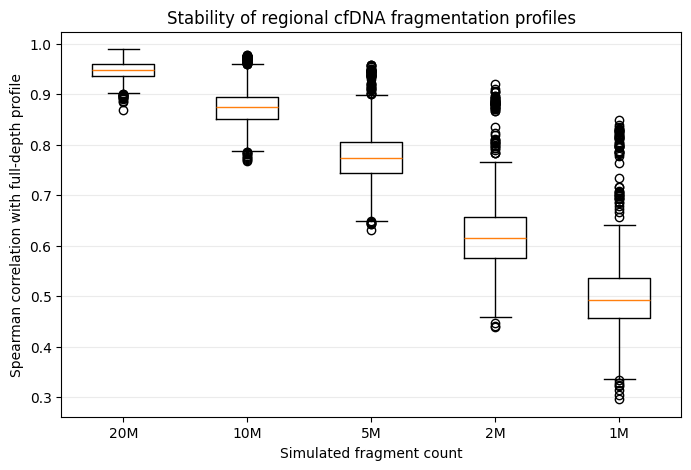

In [56]:
import matplotlib.pyplot as plt

depth_order = [
    20_000_000,
    10_000_000,
    5_000_000,
    2_000_000,
    1_000_000
]

plot_data = [
    stability_df.loc[
        stability_df["target_depth"] == depth,
        "spearman_rho"
    ]
    for depth in depth_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    plot_data,
    tick_labels=["20M", "10M", "5M", "2M", "1M"]
)

plt.ylabel("Spearman correlation with full-depth profile")
plt.xlabel("Simulated fragment count")
plt.title("Stability of regional cfDNA fragmentation profiles")
plt.grid(axis="y", alpha=0.25)

plt.show()

## 10. Classification Performance Across Sequencing Depths

To determine whether reduced sequencing depth affected diagnostic performance, the regional fragmentation classifier was reevaluated at each simulated fragment count.

Cross-validation was performed at the biological sample level so that downsampling replicates from the same sample were not split between training and testing. ROC-AUC was used as the primary performance metric, with accuracy, F1 score, and balanced accuracy reported as supporting measures.

In [57]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    balanced_accuracy_score
)

depth_results = []

depth_order = [
    20_000_000,
    10_000_000,
    5_000_000,
    2_000_000,
    1_000_000
]

for depth in depth_order:

    depth_df = simulation_df[
        simulation_df["target_depth"] == depth
    ].copy()

    X_depth = depth_df[stable_regional_features]
    y_depth = (
        depth_df["group"] == "Breast cancer"
    ).astype(int)

    groups = depth_df["sample_id"]

    cv_depth = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_metrics = []

    for train_idx, test_idx in cv_depth.split(
        X_depth,
        y_depth,
        groups=groups
    ):

        X_train = X_depth.iloc[train_idx]
        X_test = X_depth.iloc[test_idx]

        y_train = y_depth.iloc[train_idx]
        y_test = y_depth.iloc[test_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                penalty="l2",
                C=1.0,
                max_iter=5000
            ))
        ])

        model.fit(X_train, y_train)

        probabilities = model.predict_proba(X_test)[:, 1]
        predictions = model.predict(X_test)

        fold_metrics.append({
            "roc_auc": roc_auc_score(
                y_test,
                probabilities
            ),
            "accuracy": accuracy_score(
                y_test,
                predictions
            ),
            "f1": f1_score(
                y_test,
                predictions
            ),
            "balanced_accuracy":
                balanced_accuracy_score(
                    y_test,
                    predictions
                )
        })

    fold_df = pd.DataFrame(fold_metrics)

    depth_results.append({
        "target_depth": depth,
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_sd": fold_df["roc_auc"].std(),
        "accuracy_mean": fold_df["accuracy"].mean(),
        "f1_mean": fold_df["f1"].mean(),
        "balanced_accuracy_mean":
            fold_df["balanced_accuracy"].mean()
    })

depth_model_results = pd.DataFrame(depth_results)

display(depth_model_results)

,target_depth,roc_auc_mean,roc_auc_sd,accuracy_mean,f1_mean,balanced_accuracy_mean
0,20000000,0.889159,0.062688,0.810497,0.806570,0.812056
1,10000000,0.899283,0.063228,0.818567,0.816591,0.819889
2,5000000,0.857623,0.072018,0.781901,0.778294,0.782722
3,2000000,0.715596,0.053503,0.650556,0.649343,0.651222
4,1000000,0.702510,0.050357,0.650556,0.648511,0.650889


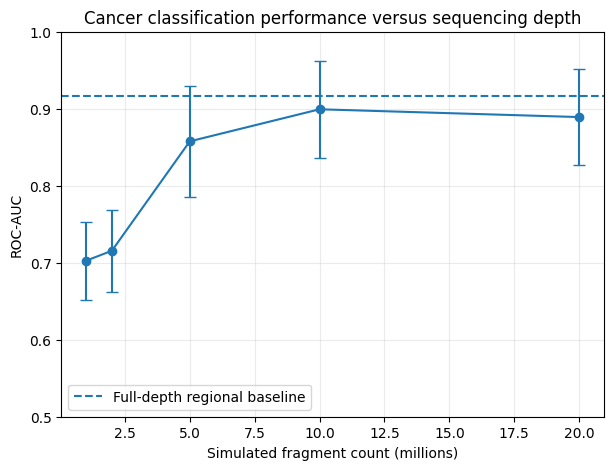

In [58]:
import matplotlib.pyplot as plt

plot_df = depth_model_results.sort_values(
    "target_depth",
    ascending=False
)

plt.figure(figsize=(7, 5))

plt.errorbar(
    plot_df["target_depth"] / 1e6,
    plot_df["roc_auc_mean"],
    yerr=plot_df["roc_auc_sd"],
    marker="o",
    capsize=4
)

plt.axhline(
    0.917,
    linestyle="--",
    label="Full-depth regional baseline"
)

plt.xlabel("Simulated fragment count (millions)")
plt.ylabel("ROC-AUC")
plt.title("Cancer classification performance versus sequencing depth")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.25)
plt.legend()

plt.show()

### Stability Interpretation

Regional fragmentation profiles became progressively less concordant with the full-depth reference as sequencing depth decreased. Median profile correlation remained high at 20M fragments but declined substantially at 5M, 2M, and 1M, indicating increasing instability in regional measurements at lower fragment counts.

## 10. Classification Performance Across Sequencing Depths

To determine whether reduced sequencing depth affected diagnostic performance, cancer-versus-healthy classification was evaluated independently at each simulated fragment count.

Regional fragmentation features were used with logistic regression and standardized within the modeling pipeline. Cross-validation was performed at the biological sample level to prevent information from the same sample from contributing to both training and testing. Performance was evaluated across 20 independent downsampling replicates at each sequencing depth, allowing both average classification performance and variability introduced by reduced fragment sampling to be assessed.

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

replicate_results = []

depth_order = [
    20_000_000,
    10_000_000,
    5_000_000,
    2_000_000,
    1_000_000
]

for depth in depth_order:

    print(f"Processing {depth/1e6:.0f}M...")

    for replicate in range(20):

        rep_df = simulation_df[
            (simulation_df["target_depth"] == depth) &
            (simulation_df["replicate"] == replicate)
        ].copy()

        X_rep = rep_df[stable_regional_features]
        y_rep = (
            rep_df["group"] == "Breast cancer"
        ).astype(int)

        # Same folds for every depth/replicate
        cv_rep = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                penalty="l2",
                C=1.0,
                max_iter=5000
            ))
        ])

        scores = cross_validate(
            model,
            X_rep,
            y_rep,
            cv=cv_rep,
            scoring={
                "roc_auc": "roc_auc",
                "accuracy": "accuracy",
                "f1": "f1",
                "balanced_accuracy": "balanced_accuracy"
            },
            n_jobs=-1
        )

        replicate_results.append({
            "target_depth": depth,
            "replicate": replicate,
            "roc_auc": scores["test_roc_auc"].mean(),
            "accuracy": scores["test_accuracy"].mean(),
            "f1": scores["test_f1"].mean(),
            "balanced_accuracy":
                scores["test_balanced_accuracy"].mean()
        })

replicate_depth_results = pd.DataFrame(replicate_results)

print("\nFinished.")
print("Shape:", replicate_depth_results.shape)

display(
    replicate_depth_results
    .groupby("target_depth")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_sd=("roc_auc", "std"),
        accuracy_mean=("accuracy", "mean"),
        f1_mean=("f1", "mean"),
        balanced_accuracy_mean=("balanced_accuracy", "mean")
    )
    .sort_index(ascending=False)
)

Processing 20M...
Processing 10M...
Processing 5M...
Processing 2M...
Processing 1M...

Finished.
Shape: (100, 6)


,roc_auc_mean,roc_auc_sd,accuracy_mean,f1_mean,balanced_accuracy_mean
target_depth,,,,,
20000000,0.871062,0.029898,0.798509,0.788495,0.801000
10000000,0.821519,0.037424,0.740146,0.726223,0.742000
5000000,0.803037,0.054402,0.722427,0.709904,0.724611
2000000,0.655173,0.079459,0.607807,0.597032,0.608889
1000000,0.619136,0.072038,0.587749,0.573427,0.588167


### 10.1 Classification Performance Summary

Classification results from the 20 downsampling replicates were summarized at each sequencing depth. Mean ROC-AUC and its variability were calculated to evaluate how diagnostic performance changed as fragment counts decreased.

Performance at each simulated depth was also compared with the full-depth regional model to determine the extent to which predictive performance was retained after downsampling.

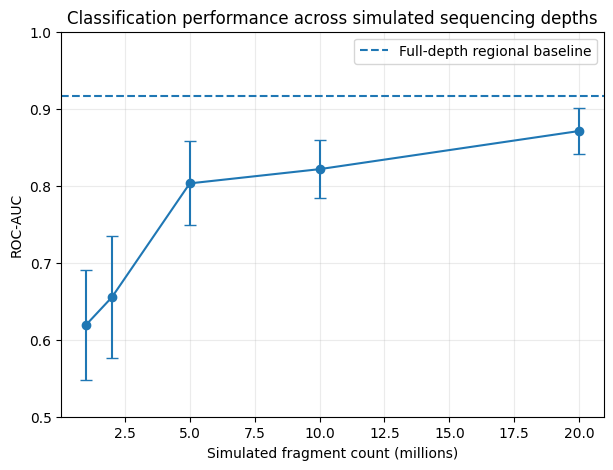

In [60]:
summary_depth = (
    replicate_depth_results
    .groupby("target_depth")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_sd=("roc_auc", "std")
    )
    .reset_index()
    .sort_values("target_depth")
)

plt.figure(figsize=(7, 5))

plt.errorbar(
    summary_depth["target_depth"] / 1e6,
    summary_depth["roc_auc_mean"],
    yerr=summary_depth["roc_auc_sd"],
    marker="o",
    capsize=4
)

plt.axhline(
    0.917,
    linestyle="--",
    label="Full-depth regional baseline"
)

plt.xlabel("Simulated fragment count (millions)")
plt.ylabel("ROC-AUC")
plt.title("Classification performance across simulated sequencing depths")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.25)
plt.legend()

plt.show()

### 10.2 Classification Results and Output Files

Depth-specific classification results, regional-profile stability measurements, and summary statistics were saved as processed output tables for reproducibility and downstream reporting.

In [61]:
# Save final analysis outputs

stability_df.to_csv(
    PROCESSED_DIR / "depth_profile_stability.csv",
    index=False
)

replicate_depth_results.to_csv(
    PROCESSED_DIR / "depth_classification_results.csv",
    index=False
)

summary_depth.to_csv(
    PROCESSED_DIR / "depth_classification_summary.csv",
    index=False
)

feature_comparison.to_csv(
    PROCESSED_DIR / "global_feature_comparison.csv",
    index=False
)

global_features.to_csv(
    PROCESSED_DIR / "cohort_global_features.csv",
    index=False
)

centered_matrix.to_csv(
    PROCESSED_DIR / "cohort_centered_regional_features.csv",
    index=False
)

print("All final analysis tables saved.")

All final analysis tables saved.


## 11. Final Results and Figures

The final figures summarize the main findings of the analysis: cohort-level sequencing depth, classification performance across feature sets, regional profile stability under downsampling, and classification performance across simulated sequencing depths.

These figures were generated from the finalized cohort-level analysis and saved for use in the project report.

### 11.1 Sequencing Depth by Study Group

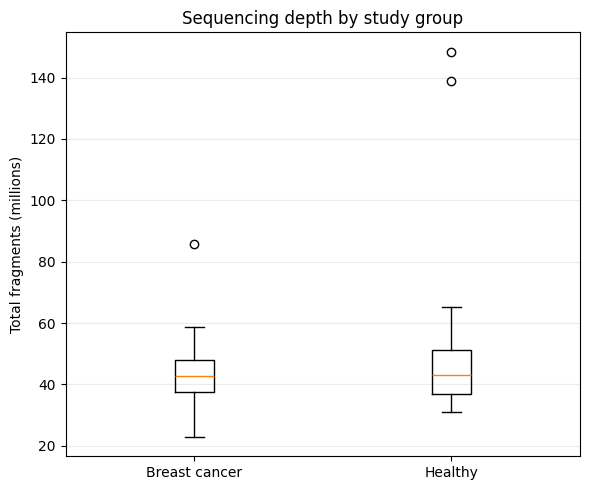

Figure 1 saved.


In [62]:
import matplotlib.pyplot as plt

cancer_depth = qc.loc[
    qc["group"] == "Breast cancer",
    "total_fragments"
] / 1e6

healthy_depth = qc.loc[
    qc["group"] == "Healthy",
    "total_fragments"
] / 1e6

plt.figure(figsize=(6, 5))

plt.boxplot(
    [cancer_depth, healthy_depth],
    tick_labels=["Breast cancer", "Healthy"]
)

plt.ylabel("Total fragments (millions)")
plt.title("Sequencing depth by study group")

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    PROCESSED_DIR / "Figure1_QC_sequencing_depth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 1 saved.")

### 11.2 Classification by Fragmentomic Feature Set

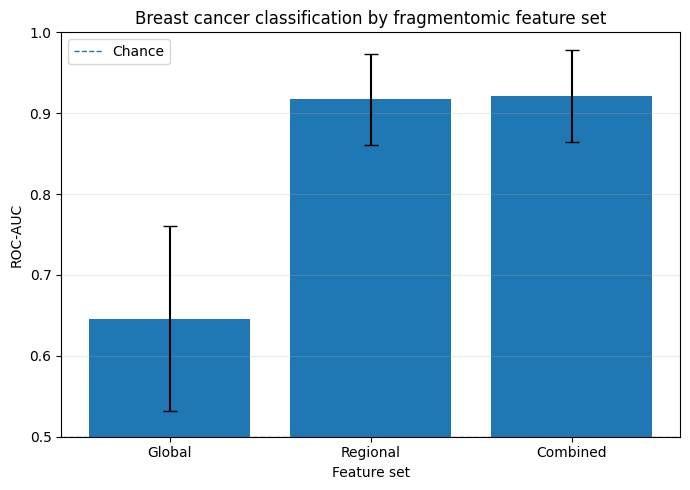

Figure 2 saved.


In [63]:
import matplotlib.pyplot as plt
import numpy as np

model_names = [
    "Global",
    "Regional",
    "Combined"
]

auc_means = [
    0.646,
    0.917,
    0.921
]

auc_sds = [
    0.114,
    0.056,
    0.057
]

x = np.arange(len(model_names))

plt.figure(figsize=(7, 5))

plt.bar(
    x,
    auc_means,
    yerr=auc_sds,
    capsize=5
)

plt.xticks(x, model_names)
plt.ylabel("ROC-AUC")
plt.xlabel("Feature set")
plt.title("Breast cancer classification by fragmentomic feature set")

plt.ylim(0.5, 1.0)
plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Chance"
)

plt.grid(axis="y", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    PROCESSED_DIR / "Figure2_feature_set_classification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 2 saved.")

Regional fragmentation features substantially outperformed global fragment-size features for breast cancer classification. The combined model produced only a small improvement beyond the regional model, indicating that most of the discriminatory signal was captured by genome-wide regional fragmentation patterns.

### 11.3 Regional Profile Stability Across Sequencing Depths

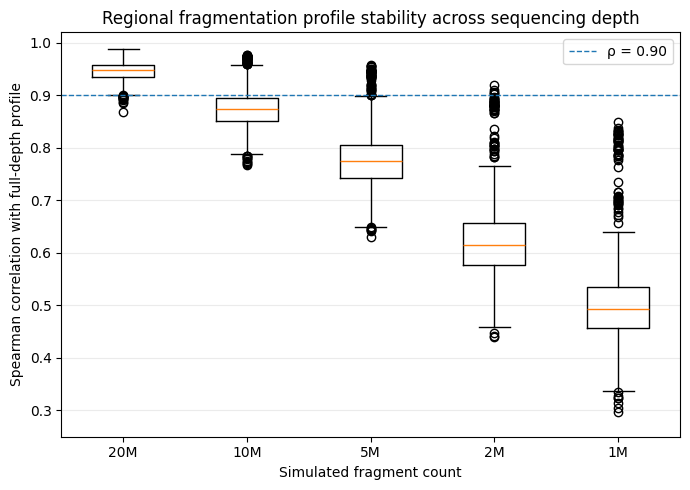

Figure 3 saved.


In [64]:
# Figure 3: Regional profile stability across simulated depth

depth_order = [
    20_000_000,
    10_000_000,
    5_000_000,
    2_000_000,
    1_000_000
]

plot_data = [
    stability_df.loc[
        stability_df["target_depth"] == depth,
        "spearman_rho"
    ]
    for depth in depth_order
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    plot_data,
    tick_labels=["20M", "10M", "5M", "2M", "1M"]
)

plt.xlabel("Simulated fragment count")
plt.ylabel("Spearman correlation with full-depth profile")
plt.title("Regional fragmentation profile stability across sequencing depth")

# Reference for high profile concordance
plt.axhline(
    0.90,
    linestyle="--",
    linewidth=1,
    label="ρ = 0.90"
)

plt.ylim(0.25, 1.02)
plt.grid(axis="y", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    PROCESSED_DIR / "Figure3_profile_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 3 saved.")

### 11.4 Classification Performance Across Sequencing Depths

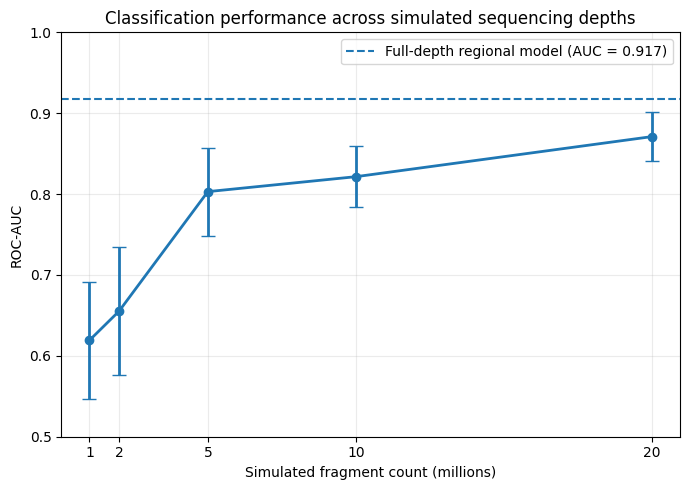

Figure 4 saved.


In [65]:
# Figure 4: Classification performance across simulated sequencing depths

summary_plot = (
    replicate_depth_results
    .groupby("target_depth")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_sd=("roc_auc", "std")
    )
    .reset_index()
    .sort_values("target_depth")
)

plt.figure(figsize=(7, 5))

plt.errorbar(
    summary_plot["target_depth"] / 1e6,
    summary_plot["roc_auc_mean"],
    yerr=summary_plot["roc_auc_sd"],
    marker="o",
    capsize=5,
    linewidth=2
)

# Full-depth regional model
plt.axhline(
    0.917,
    linestyle="--",
    linewidth=1.5,
    label="Full-depth regional model (AUC = 0.917)"
)

plt.xlabel("Simulated fragment count (millions)")
plt.ylabel("ROC-AUC")
plt.title("Classification performance across simulated sequencing depths")

plt.xticks([1, 2, 5, 10, 20])
plt.ylim(0.5, 1.0)

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    PROCESSED_DIR / "Figure4_depth_classification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 4 saved.")

## 12. Conclusions

Genome-wide regional cfDNA fragmentation patterns provided substantially stronger breast cancer classification than global fragment-size summaries. Regional classification reached approximately 0.92 ROC-AUC at full depth, while global features alone achieved approximately 0.65.

Simulated reductions in sequencing depth progressively decreased both regional profile stability and classification performance. Performance remained relatively strong at 20M fragments and retained useful discrimination at 10M–5M fragments, but deteriorated substantially at 2M and 1M fragments.

These results suggest that regional cfDNA fragmentation is more diagnostically informative than global fragment-size summaries, while also demonstrating that its analytical reliability depends on sufficient sequencing depth. The observed depth-performance relationship should be validated in an independent cohort before defining a minimum sequencing requirement for clinical use.

## Reproducibility

The complete analysis workflow, preprocessing script, processed cohort data, final figures, result tables, and computational environment are available in the public GitHub repository:

https://github.com/nelly-abualkheir/cfDNA-fragmentomics-depth

The repository includes the final analysis notebook, `process_fragments.py`, `environment.yml`, processed data required for downstream analysis, and documentation for reproducing the workflow. Large raw fragment-level files are not included because of their size and can be obtained from the original public data source.